Code for analyzing precipitation from HighResMIP historical simulations (highresSST-present, 1950--2014) and comparing model output to a suite of observational/reanalysis precipitation products.

Relevant for manuscript Figure 2 and Supplemental Figures S2, S3, S4

In [10]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import xarray as xr
xr.set_options(keep_attrs=True)
import numpy as np
np.seterr(divide='ignore', invalid='ignore')
from scipy.ndimage import gaussian_filter1d
from scipy.stats import binned_statistic
import pyproj

import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.ops import transform
from shapely.geometry import LineString

import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib import cm
import matplotlib.patheffects as path_effects

# settings
%config InlineBackend.figure_format = 'retina'

# add path to custom functions
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path+"/py_functions")
from colorbar_funcs import *
from data_funcs import *
from stats_funcs import *
from domain_funcs import *

dpath0='/discover/nobackup/projects/giss/baldwin_nip/dmkumar'

In [2]:
models=['CAM-MPAS',
        'CAMS-CSM1-0',
        'CMCC-CM2',
        'CNRM-CM6-1',
        'EC-Earth3P',
        'ECMWF-IFS',
        'FGOALS-f3',
        'GFDL-CM4',
        'HadGEM3-GC31',
        'HiRAM-SIT',
        'INM-CM5',
        'IPSL-CM6A',
        'MPI-ESM1-2',
        'MRI-ESM2',
        'NICAM16']

lr_map = {
    'CAM-MPAS': ['CAM-MPAS-LR'],
    'CAMS-CSM1-0': ['CAMS-CSM1-0-LR'],
    'CMCC-CM2': ['CMCC-CM2-HR4'],
    'CNRM-CM6-1': ['CNRM-CM6-1'],
    'EC-Earth3P': [],
    'ECMWF-IFS': ['ECMWF-IFS-LR'],
    'FGOALS-f3': ['FGOALS-f3-L'],
    'GFDL-CM4': ['GFDL-CM4'],
    'HadGEM3-GC31': ['HadGEM3-GC31-LM'],
    'HiRAM-SIT': [],
    'INM-CM5': ['INM-CM5-0'],
    'IPSL-CM6A': ['IPSL-CM6A-LR'],
    'MPI-ESM1-2': ['MPI-ESM1-2-LR'],
    'MRI-ESM2': ['MRI-ESM2-0'],
    'NICAM16': [],
}

hr_map = {
    'CAM-MPAS': ['CAM-MPAS-HR'],
    'CAMS-CSM1-0': ['CAMS-CSM1-0'],
    'CMCC-CM2': ['CMCC-CM2-VHR4'],
    'CNRM-CM6-1': ['CNRM-CM6-1-HR'],
    'EC-Earth3P': ['EC-Earth3P', 'EC-Earth3P-HR'],
    'ECMWF-IFS': ['ECMWF-IFS-HR'],
    'FGOALS-f3': ['FGOALS-f3-H'],
    'GFDL-CM4': ['GFDL-CM4C192'],
    'HadGEM3-GC31': ['HadGEM3-GC31-MM', 'HadGEM3-GC31-HM'],
    'HiRAM-SIT': ['HiRAM-SIT-LR', 'HiRAM-SIT-HR'],
    'INM-CM5': ['INM-CM5-H'],
    'IPSL-CM6A': ['IPSL-CM6A-ATM-HR'],
    'MPI-ESM1-2': ['MPI-ESM1-2-HR', 'MPI-ESM1-2-XR'],
    'MRI-ESM2': ['MRI-AGCM3-2-H', 'MRI-AGCM3-2-S'],
    'NICAM16': ['NICAM16-7S', 'NICAM16-8S'],
}

In [3]:
## +++ DEFINE SUBSETTING BOUNDS +++ ##
latmin, latmax = 10, 70
lonmin, lonmax = 200, 300

In [4]:
# --- read & subset topo data --- #
etopo_full = xr.open_dataset(f'{dpath0}/topo_files/obs.etopo5.zsurf.nc').ROSE.rename({'ETOPO05_X':'lon', 'ETOPO05_Y':'lat'})
etopoNA = etopo_full.where(etopo_full>0, np.nan).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
print('Topography data loaded.')

Topography data loaded.


# INITIAL DATA PROCESSING

- Load HighResMIP and observational data
- Calculate Jul.-Sept. seasonal mean values
- Regrid obs data to model grids
- Calculate model - obs precipitation biases and significance testing

Only needs to be run 1x. Then, generates cache files for future figure iterations.

In [4]:
## +++ LOAD HRMIP DATA +++ ##

# --- store filepaths --- #
files = {}
varn = 'pr'
case = 'highresSST-present'

for model in models:
    for cfg in lr_map[model] + hr_map[model]:
        files[cfg] = f"{dpath0}/hrmip/{case}/{varn}/{varn}.Amon.{case}.{cfg}.nc"


# --- read & subset data --- #
dat    = {'lr': {}, 'hr': {}}
dat_na = {'lr': {}, 'hr': {}}

print("Working on...")
for res, rmap in {'lr': lr_map, 'hr': hr_map}.items():
    for model in models:
        for cfg in rmap[model]:
            print(f"{res.upper()} -> {cfg}")
            ds = xr.open_dataset(files[cfg], chunks={'time': 12})['pr']
            ds = ds.sortby('time').sel(time=slice('1950', '2014'))
            ds = match_lat_lon_names(ds) * 86400  # mm/s → mm/day
            ds = ds.squeeze().drop_vars([c for c in ['member_id', 'dcpp_init_year'] if c in ds.coords])
            dat[res][cfg]    = ds
            dat_na[res][cfg] = ds.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
print("Done.")

Working on...
LR -> CAM-MPAS-LR
LR -> CAMS-CSM1-0-LR
LR -> CMCC-CM2-HR4
LR -> CNRM-CM6-1
LR -> ECMWF-IFS-LR
LR -> FGOALS-f3-L
LR -> GFDL-CM4
LR -> HadGEM3-GC31-LM
LR -> INM-CM5-0
LR -> IPSL-CM6A-LR
LR -> MPI-ESM1-2-LR
LR -> MRI-ESM2-0
HR -> CAM-MPAS-HR
HR -> CAMS-CSM1-0
HR -> CMCC-CM2-VHR4
HR -> CNRM-CM6-1-HR
HR -> EC-Earth3P
HR -> EC-Earth3P-HR
HR -> ECMWF-IFS-HR
HR -> FGOALS-f3-H
HR -> GFDL-CM4C192
HR -> HadGEM3-GC31-MM
HR -> HadGEM3-GC31-HM
HR -> HiRAM-SIT-LR
HR -> HiRAM-SIT-HR
HR -> INM-CM5-H
HR -> IPSL-CM6A-ATM-HR
HR -> MPI-ESM1-2-HR
HR -> MPI-ESM1-2-XR
HR -> MRI-AGCM3-2-H
HR -> MRI-AGCM3-2-S
HR -> NICAM16-7S
HR -> NICAM16-8S
Done.


In [5]:
## +++ LOAD OBS DATA +++ ##

# --- define product keys --- #
obs_prods = ['imerg', 'trmm', 'gpcp', 'gpcc']

# --- store filepaths --- #
obs_files = {
    'imerg': f'{dpath0}/obs_data/prec/imerg.gn.timeseries.2001-2018.nc',
    'trmm':  f'{dpath0}/obs_data/prec/pr_TRMM-L3_v7-7A_199801-201312.nc',
    'gpcp':  f'{dpath0}/obs_data/prec/gpcp.precip.1979-2018.monthly.nc',
    'gpcc':  f'{dpath0}/obs_data/prec/gpcc.precip.mon.rate.0.25x0.25.v2020.nc',
}

# --- read & subset precip data --- #
obs_dat    = {prod: {} for prod in obs_prods}
obs_dat_na = {prod: {} for prod in obs_prods}

print('Working on...')
for prod in obs_prods:
    print(f"-> {prod}")
    if prod == 'imerg':
        ds = xr.open_dataset(obs_files[prod], chunks={'time': 12}).precipitation * 24  # mm/hr → mm/day
        ds = ds.transpose('time', 'lat', 'lon')
        ds.attrs['units'] = 'mm/day'
        ds.attrs['Units'] = 'mm/day'
        ds = lonFlip(ds)
    elif prod == 'trmm':
        ds = xr.open_dataset(obs_files[prod], chunks={'time': 12}).pr * 86400  # kg m-2 s-1 → mm/day
    elif prod == 'gpcp':
        ds = xr.open_dataset(obs_files[prod], chunks={}).precip
    elif prod == 'gpcc':
        ds = xr.open_dataset(obs_files[prod], chunks={}).precip.sortby("lat")
    obs_dat[prod]    = ds
    obs_dat_na[prod] = ds.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
    del ds
print('Done.\n')


Working on...
-> imerg
-> trmm
-> gpcp
-> gpcc
Done.

Topography data loaded.


In [6]:
## +++ CALCULATE JUL.-SEPT. SEASONAL MEANS +++ ##

jas_mean = {
    'lr':  {},
    'hr':  {},
    'obs': {prod: {} for prod in obs_prods},
}
ann_jas_mean = {
    'lr':  {},
    'hr':  {},
    'obs': {prod: {} for prod in obs_prods},
}

for res in ['lr', 'hr']:
    for cfg, ds in dat_na[res].items():
        jas_mean[res][cfg]     = jas_seasonal_mean(ds)
        ann_jas_mean[res][cfg] = jas_yearly_mean(ds)

for prod in obs_prods:
    jas_mean['obs'][prod]     = jas_seasonal_mean(obs_dat_na[prod])
    ann_jas_mean['obs'][prod] = jas_yearly_mean(obs_dat_na[prod])

print('Done.')

Done.


In [7]:
## +++ SIGNIFICANCE TESTING +++ ##

# --- map obs products to model grids --- #
obs_jas_mean_regrid = {prod: {'lr': {}, 'hr': {}} for prod in obs_prods}
obs_ann_jas_mean_regrid = {prod: {'lr': {}, 'hr': {}} for prod in obs_prods}

print('Regridding obs.')
for prod in obs_prods:
    for res in ['lr', 'hr']:
        for cfg, ds in dat_na[res].items():
            obs_jas_mean_regrid[prod][res][cfg] = jas_mean['obs'][prod].interp(lat=ds.lat, lon=ds.lon)
            obs_ann_jas_mean_regrid[prod][res][cfg] = ann_jas_mean['obs'][prod].interp(lat=ds.lat, lon=ds.lon)

print('Done.\n')

# --- evaluate statistical significance --- #
diff      = {prod: {'lr': {}, 'hr': {}} for prod in obs_prods}
diff_mask = {prod: {'lr': {}, 'hr': {}} for prod in obs_prods}
ptvals    = {prod: {'lr': {}, 'hr': {}} for prod in obs_prods}

print('Significance testing for:')
for prod in obs_prods:
    print(f'\n{prod}')
    for res in ['lr', 'hr']:
        print(f'->{res}')
        for cfg in dat[res]:
            print(f'--->{cfg}')
            d, m, p = sigtest2n(ann_jas_mean[res][cfg], obs_ann_jas_mean_regrid[prod][res][cfg],
                                jas_mean[res][cfg],     obs_jas_mean_regrid[prod][res][cfg])
            diff[prod][res][cfg] = d
            diff_mask[prod][res][cfg] = m
            ptvals[prod][res][cfg] = p

print('Done.')

Regridding obs.
Done.

Significance testing for:

imerg
->lr
--->CAM-MPAS-LR
--->CAMS-CSM1-0-LR
--->CMCC-CM2-HR4
--->CNRM-CM6-1
--->ECMWF-IFS-LR
--->FGOALS-f3-L
--->GFDL-CM4
--->HadGEM3-GC31-LM
--->INM-CM5-0
--->IPSL-CM6A-LR
--->MPI-ESM1-2-LR
--->MRI-ESM2-0
->hr
--->CAM-MPAS-HR
--->CAMS-CSM1-0
--->CMCC-CM2-VHR4
--->CNRM-CM6-1-HR
--->EC-Earth3P
--->EC-Earth3P-HR
--->ECMWF-IFS-HR
--->FGOALS-f3-H
--->GFDL-CM4C192
--->HadGEM3-GC31-MM
--->HadGEM3-GC31-HM
--->HiRAM-SIT-LR
--->HiRAM-SIT-HR
--->INM-CM5-H
--->IPSL-CM6A-ATM-HR
--->MPI-ESM1-2-HR
--->MPI-ESM1-2-XR
--->MRI-AGCM3-2-H
--->MRI-AGCM3-2-S
--->NICAM16-7S
--->NICAM16-8S

trmm
->lr
--->CAM-MPAS-LR
--->CAMS-CSM1-0-LR
--->CMCC-CM2-HR4
--->CNRM-CM6-1
--->ECMWF-IFS-LR
--->FGOALS-f3-L
--->GFDL-CM4
--->HadGEM3-GC31-LM
--->INM-CM5-0
--->IPSL-CM6A-LR
--->MPI-ESM1-2-LR
--->MRI-ESM2-0
->hr
--->CAM-MPAS-HR
--->CAMS-CSM1-0
--->CMCC-CM2-VHR4
--->CNRM-CM6-1-HR
--->EC-Earth3P
--->EC-Earth3P-HR
--->ECMWF-IFS-HR
--->FGOALS-f3-H
--->GFDL-CM4C192
--->HadGEM3

# Start Here on Re-Runs

In [5]:
## +++ CREATE COMBINED DICT OF HIGH- & LOW-RES. BIASES +++ ##

# Precip products
obs_prods = ['imerg', 'trmm', 'gpcp', 'gpcc']

# lat/lon bounds for broad NAM domain subset
ymin, ymax = 15, 45
xmin, xmax = 240, 270

# Config lists derived from lr_map/hr_map
all_cfgs = {
    'lr': [cfg for m in models for cfg in lr_map[m]],
    'hr': [cfg for m in models for cfg in hr_map[m]],
}
all_cfgs_flat = all_cfgs['lr'] + all_cfgs['hr']

# --- Cache logic ---
# Each per-config NetCDF stores, on the model grid: one bias map per obs product
# (variables named by obs product), the JAS precip climatology map (variable 'climo'),
# and the full-grid longitude count as a file attribute (for resolution coloring).
# On re-runs: if all cache files exist, load directly and skip ALL upstream cells.
cache_dir = '../highresmip_diagnostics/cache/'
cache_files = {cfg: os.path.join(cache_dir, f'pr_bias_{cfg}.nc') for cfg in all_cfgs_flat}
obs_cache_file = os.path.join(cache_dir, 'jas_mean_obs.nc')
use_cache = all(os.path.exists(f) for f in cache_files.values()) and os.path.exists(obs_cache_file)

if use_cache:
    print("Loading allmodels from cache...")
    allmodels = {prod: {} for prod in obs_prods}
    allmodels_climo = {}
    allmodels_res = {}
    for res in ['lr', 'hr']:
        for cfg in all_cfgs[res]:
            ds = xr.open_dataset(cache_files[cfg])
            for prod in obs_prods:
                allmodels[prod][cfg] = ds[prod]
            allmodels_climo[cfg] = ds['climo'].load()
            allmodels_res[cfg] = int(ds.attrs['nlon'])
    ds_obs = xr.open_dataset(obs_cache_file)
    jas_mean = {'obs': {prod: ds_obs[prod] for prod in obs_prods}}
    print("Done.")
else:
    print("Computing allmodels (cache will be written for future runs)...")
    allmodels = {prod: {} for prod in obs_prods}
    for prod in obs_prods:
        for res in ['lr', 'hr']:
            for cfg, da in diff[prod][res].items():
                allmodels[prod][cfg] = da.sel(lat=slice(ymin, ymax), lon=slice(xmin, xmax)).load()

    # JAS precip climatology maps (model field, not bias) for the climatology-map figure
    allmodels_climo = {}
    for res in ['lr', 'hr']:
        for cfg in all_cfgs[res]:
            allmodels_climo[cfg] = jas_mean[res][cfg].sel(lat=slice(ymin, ymax), lon=slice(xmin, xmax)).load()

    # Full-grid lon counts from dat (only needed on first run)
    allmodels_res = {}
    for res in ['lr', 'hr']:
        for cfg, da in dat[res].items():
            allmodels_res[cfg] = len(da.lon)

    # Save one NetCDF per config: obs-product bias variables + 'climo' map + nlon attribute
    os.makedirs(cache_dir, exist_ok=True)
    for res in ['lr', 'hr']:
        for cfg in all_cfgs[res]:
            ds_out = xr.Dataset({prod: allmodels[prod][cfg] for prod in obs_prods})
            ds_out['climo'] = allmodels_climo[cfg]
            ds_out.attrs['nlon'] = allmodels_res[cfg]
            ds_out.to_netcdf(cache_files[cfg])
    xr.Dataset({prod: jas_mean['obs'][prod] for prod in obs_prods}).to_netcdf(obs_cache_file)
    print(f"Saved {len(all_cfgs_flat)} cache files to {cache_dir}")

sorted_models = {}

for prod in obs_prods:
    sorted_models[prod] = dict(sorted(allmodels[prod].items(), key=lambda item: len(item[1].coords["lon"])))


Loading allmodels from cache...
Done.


In [6]:
## +++ GET INFO ABOUT MODEL RESOLUTIONS +++ ##

# allmodels_res: {cfg: nlon_int}, sorted by resolution ascending
allmodels_res = dict(sorted(allmodels_res.items(), key=lambda item: item[1]))

lowres_counts  = {cfg: allmodels_res[cfg] for cfg in all_cfgs['lr']}
highres_counts = {cfg: allmodels_res[cfg] for cfg in all_cfgs['hr']}

# compute medians
median_lowres = np.median(list(lowres_counts.values()))
median_highres = np.median(list(highres_counts.values()))

# compute means
mean_lowres = np.mean(list(lowres_counts.values()))
mean_highres = np.mean(list(highres_counts.values()))

# find configuration(s) exactly at the median
median_lowres_configs = [cfg for cfg, n in lowres_counts.items() if n == median_lowres]
median_highres_configs = [cfg for cfg, n in highres_counts.items() if n == median_highres]

# find configuration closest to the mean
mean_lowres_config = min(lowres_counts, key=lambda cfg: abs(lowres_counts[cfg] - mean_lowres))
mean_highres_config = min(highres_counts, key=lambda cfg: abs(highres_counts[cfg] - mean_highres))

print(f"Median low-resolution grid size (lon): {median_lowres}")
print(f"Configuration(s) with median low resolution: {median_lowres_configs}\n")
print(f"Median high-resolution grid size (lon): {median_highres}")
print(f"Configuration(s) with median high resolution: {median_highres_configs}\n")

print(f"Mean low-resolution grid size (lon): {mean_lowres}")
print(f"Closest configuration to mean low resolution: {mean_lowres_config}\n")
print(f"Mean high-resolution grid size (lon): {mean_highres}")
print(f"Closest configuration to mean high resolution: {mean_highres_config}")

Median low-resolution grid size (lon): 288.0
Configuration(s) with median low resolution: ['CMCC-CM2-HR4', 'FGOALS-f3-L', 'GFDL-CM4']

Median high-resolution grid size (lon): 720.0
Configuration(s) with median high resolution: ['CNRM-CM6-1-HR', 'ECMWF-IFS-HR', 'HiRAM-SIT-LR']

Mean low-resolution grid size (lon): 265.6666666666667
Closest configuration to mean low resolution: CNRM-CM6-1

Mean high-resolution grid size (lon): 892.7619047619048
Closest configuration to mean high resolution: CAMS-CSM1-0


In [7]:
## +++ CALCULATE MULTI-MODEL ENSEMBLE MEAN BIASES +++ ##

mme = {'lr':{ prod:{} for prod in obs_prods },
       'hr':{ prod:{} for prod in obs_prods } }

# Target grids: lowest-resolution model in each set
res_key = {'lr': 'IPSL-CM6A-LR', 'hr': 'IPSL-CM6A-ATM-HR'}

for config, cfg_map in {'lr': lr_map, 'hr': hr_map}.items():
    for prod in obs_prods:
        target = allmodels[prod][res_key[config]]
        slices = []
        for model in models:
            for cfg in cfg_map[model]:
                ds = allmodels[prod][cfg].assign_coords(source_id=cfg)
                slices.append(ds.interp(lat=target.lat.values, lon=target.lon.values))
        mme[config][prod] = xr.concat(slices, dim='source_id').mean(dim='source_id')

In [8]:
## +++ CALCULATE AREA-WEIGHTED MEAN PR BIASES +++ ##

# --- load pre-set sub-domain boundaries --- #
coords_map, regions = nam_regions()
domains = list(coords_map.keys())

# --- calculate sub-domain-mean biases --- #
resolutions = ['lr', 'hr']
nam_bias = {res: {d: {} for d in domains} for res in resolutions}

for res in resolutions:
    for domain in domains:
        for cfg in all_cfgs[res]:
            if cfg not in allmodels['imerg']:
                continue
            bias = allmodels['imerg'][cfg]
            bias_mean = regional_weighted_mean(bias, regions).sel(region=domain).load()
            nam_bias[res][domain][cfg] = {"bias": bias_mean}

In [16]:
## +++ CALCULATE MEAN BIAS PROFILES ACROSS TRANSECT +++ ##

# Choose which observational produce to construct profiles for
prod = 'imerg'

npoints = 200
transect_lat_max, transect_lat_min = 28.5, 21.5
transect_lon_max, transect_lon_min = 250.2, 255.5

transect_lats = np.linspace(transect_lat_max, transect_lat_min, npoints)
transect_lons = np.linspace(transect_lon_max, transect_lon_min, npoints)

# Projection centered near transect midpoint
lon0, lat0 = np.mean(transect_lons), np.mean(transect_lats)
proj = pyproj.Proj(proj="aeqd", lat_0=lat0, lon_0=lon0)

# Project transect to planar coordinates
transect_x, transect_y = proj(transect_lons, transect_lats)
transect_coords = np.column_stack((transect_x, transect_y))
transect_line = LineString(transect_coords)

# >>> KNOB: half-width of the swath (km). Narrowing to ~150-200 focuses the profile on
#     the near-transect +50..+150 km wet band and drops the dry far-NE tail (>+200 km).
#     Also sets the profile's x-axis range. <<<
buffer_km = 300

# Cross-transect (perpendicular-distance) bins for the profile
nbins = 60
bin_edges   = np.linspace(-buffer_km, buffer_km, nbins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Transect direction (v) and normal (n, NE = positive) in the projected plane.
# The straight-line decomposition below matches the 2-D along/perp diagnostic exactly.
_Sx, _Sy = transect_x[0], transect_y[0]
_dx, _dy = transect_x[-1] - _Sx, transect_y[-1] - _Sy
_L = np.hypot(_dx, _dy)
_vx, _vy = _dx / _L, _dy / _L          # unit along-transect (NW -> SE)
_nx, _ny = -_vy, _vx                   # unit normal; NE side is positive for this transect


def extract_transect_profile(da):
    """Cross-transect precipitation-bias profile from a 2D (lat, lon) bias map.

    Decomposes each grid cell into along-transect and signed perpendicular (NE = positive)
    coordinates, keeps the strip beside the transect (0 <= along <= L, |perp| <= buffer_km),
    bins by perpendicular distance and returns the MEAN bias per bin, Gaussian-smoothed by
    the native grid spacing. Aligned with bin_centers.

    Note: this drops the semicircular "end caps" beyond the transect endpoints. A
    point-to-polyline distance would clamp those cells to the endpoint distance, landing
    them in the wrong perpendicular bins and washing out the NE wet lobe.
    """
    lon2d, lat2d = np.meshgrid(da.lon.values, da.lat.values)
    x2d, y2d = proj(lon2d, lat2d)

    rel_x = (x2d - _Sx).ravel()
    rel_y = (y2d - _Sy).ravel()
    along = rel_x * _vx + rel_y * _vy      # meters along the transect (0 at NW start)
    perp  = rel_x * _nx + rel_y * _ny      # meters perpendicular, signed (NE positive)

    # Keep only the strip beside the transect (no end caps), within +/- buffer perpendicular
    within = (np.abs(perp) <= buffer_km * 1000) & (along >= 0) & (along <= _L)
    distances   = perp[within] / 1000      # meters -> km (signed; NE positive)
    precip_vals = da.values.ravel()[within]
    if len(distances) <= 1:
        return np.full(nbins, np.nan)

    # --- per-perpendicular-distance bin MEAN (preserves the cross-transect dipole) ---
    prof, _, _ = binned_statistic(distances, precip_vals, statistic='mean', bins=bin_edges)

    # Fill any empty bins (sparse/coarse maps) so the Gaussian smooth doesn't spread NaNs
    valid = ~np.isnan(prof)
    if valid.sum() <= 1:
        return np.full(nbins, np.nan)
    prof = np.interp(bin_centers, bin_centers[valid], prof[valid])

    # Gaussian smooth by ~one native grid cell (km)
    dlon = np.abs(np.diff(da.lon.values)).mean()
    dlat = np.abs(np.diff(da.lat.values)).mean()
    grid_km = 111 * np.sqrt(dlon**2 + dlat**2)
    sigma_pts = max(grid_km / (bin_centers[1] - bin_centers[0]), 1)
    return gaussian_filter1d(prof, sigma=sigma_pts)


# --- Individual-model profiles (plotted as the thin lines in Fig. 2D) ---
transect_profiles = {}
for name, da in sorted_models[prod].items():
    transect_profiles[name] = {
        "bin_centers": bin_centers,
        "profile": extract_transect_profile(da),
    }

#=== Multi-model ensemble-mean profiles for Low-Res. and High-Res. configs.
# >>> KNOB: how the thick MME lines (Fig. 2D) are computed. A/B these two: <<<
#   'map'      -> transect through the MME mean spatial map (mme[res][prod]); this is
#                 consistent with the maps in panels E/F and shows the NE positive blob.
#   'profiles' -> mean of the individual per-model profiles; reflects the typical member
#                 and is muted where the ensemble disagrees on the NE wet bias.
MME_METHOD = 'profiles'

if MME_METHOD == 'map':
    lr_mean = extract_transect_profile(mme['lr'][prod])
    hr_mean = extract_transect_profile(mme['hr'][prod])
elif MME_METHOD == 'profiles':
    lr_profiles = []
    hr_profiles = []
    for model in models:
        for cfg in lr_map[model]:
            if cfg in transect_profiles:
                lr_profiles.append(transect_profiles[cfg]["profile"])
        for cfg in hr_map[model]:
            if cfg in transect_profiles:
                hr_profiles.append(transect_profiles[cfg]["profile"])
    lr_mean = np.nanmean(np.array(lr_profiles), axis=0)
    hr_mean = np.nanmean(np.array(hr_profiles), axis=0)
else:
    raise ValueError(f"MME_METHOD must be 'map' or 'profiles', got {MME_METHOD!r}")


# FIGURES

In [17]:
## +++ PLOTTING FUNCTIONS +++ ##

def make_transect_patch_exact(transect_lons, transect_lats, buffer_km):
    lon0, lat0 = np.mean(transect_lons), np.mean(transect_lats)
    proj_aeqd   = pyproj.Proj(proj="aeqd", lat_0=lat0, lon_0=lon0)
    proj_latlon = pyproj.Proj(proj="latlong", datum="WGS84")

    transformer_to_latlon = pyproj.Transformer.from_proj(proj_aeqd, proj_latlon, always_xy=True).transform

    transect_xy = [proj_aeqd(lon, lat) for lon, lat in zip(transect_lons, transect_lats)]
    line_proj = LineString(transect_xy)

    # Flat ends (cap_style=2) + straight sides (join_style=2)
    patch_proj = line_proj.buffer(buffer_km * 1000, cap_style=2, join_style=2)

    patch_lonlat = transform(transformer_to_latlon, patch_proj)
    return patch_lonlat

transect_patch = make_transect_patch_exact(transect_lons, transect_lats, buffer_km=buffer_km/2)
transect_line = LineString(zip((360-transect_lons)*-1, transect_lats))

def plot_panel_horizontal(ax, domain, metric):
    line_kw = dict(color='0.7', lw=2, zorder=1)
    marker_kw = dict(marker='s', edgecolor='k', linewidth=0.8, zorder=3)

    sort_vals = {}
    for model in models:
        hr_cfgs = hr_map.get(model, [])
        if hr_cfgs:
            # pick the max magnitude among HR configs
            sort_vals[model] = max(
                abs(nam_bias['hr'][domain][cfg][metric]) for cfg in hr_cfgs
            )
    models_sorted = sorted(models, key=lambda m: sort_vals[m], reverse=False)  # largest first

    yvals = np.arange(len(models_sorted))
    for y, model in zip(yvals, models_sorted):

        lr_cfgs = lr_map.get(model, [])
        hr_cfgs = hr_map.get(model, [])

        # collect values for plotting
        lr_vals, lr_sizes = [], []
        hr_vals, hr_sizes = [], []

        for lr_cfg in lr_cfgs:
            lr_val = nam_bias['lr'][domain][lr_cfg][metric]
            lr_vals.append(lr_val)
            lr_sizes.append(40000 / lowres_counts[lr_cfg])

        for hr_cfg in hr_cfgs:
            hr_val = nam_bias['hr'][domain][hr_cfg][metric]
            hr_vals.append(hr_val)
            hr_sizes.append(40000 / highres_counts[hr_cfg])

        # Plot LR points
        for val, size in zip(lr_vals, lr_sizes):
            ax.scatter(val, y, s=size, facecolor='black', **marker_kw)

        # Plot HR points
        for val, size in zip(hr_vals, hr_sizes):
            ax.scatter(val, y, s=size, facecolor='darkgoldenrod', **marker_kw)

        # Connect each LR -> each HR
        for lr_val in lr_vals:
            for hr_val in hr_vals:
                ax.plot([lr_val, hr_val], [y, y], **line_kw)

        # Connect HR points among themselves if multiple HR configs
        if len(hr_vals) > 1:
            hr_sorted = sorted(hr_vals)
            ax.plot(hr_sorted, [y]*len(hr_sorted), **line_kw)  # slightly lighter line

    ax.axvline(0, color='k', ls='--', lw=1)
    ax.set_yticks(yvals)
    ax.set_yticklabels(models_sorted)
    ax.invert_yaxis()
    ax.xaxis.tick_top()
    ax.tick_params(axis='x', bottom=False, labelbottom=False)

### Figure 2: Characterization of HighResMIP biases

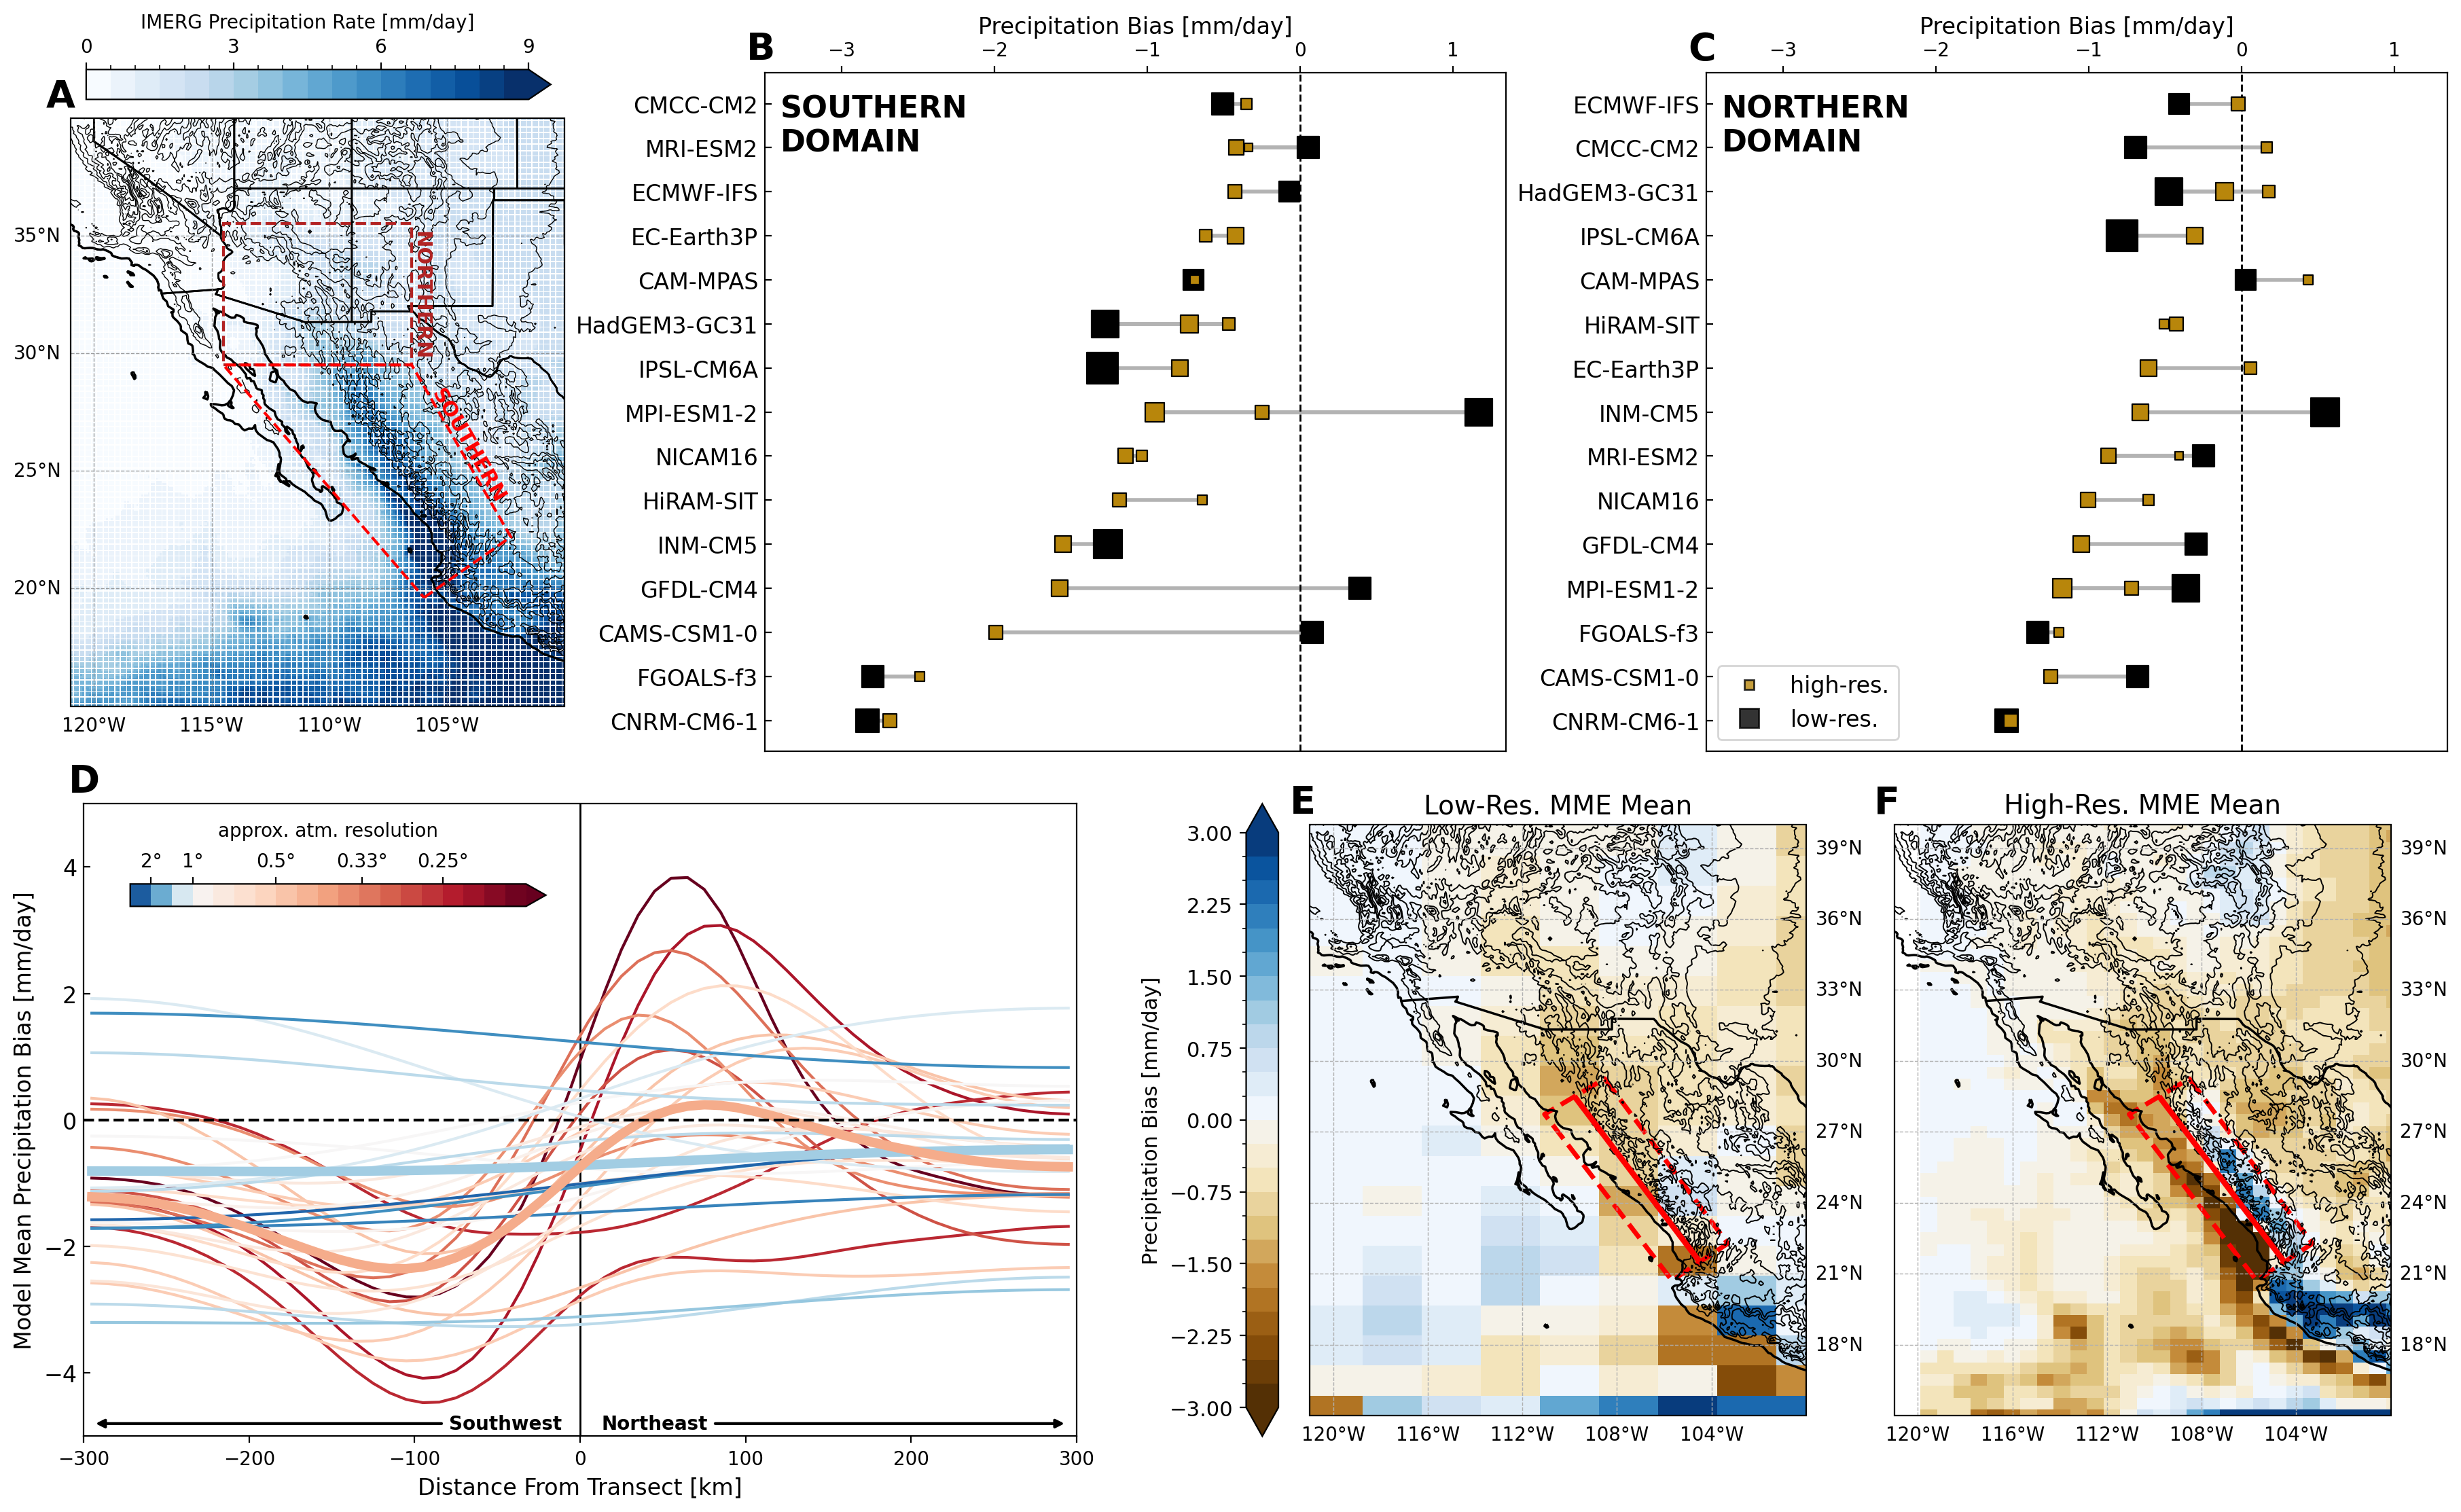

In [29]:
# choose which obs product to plot biases against
prod = 'imerg'

# --- settings --- #
text_kw={'size':16, 'weight':'bold', 'color':'k', 'ha':'left', 'va':'center'}
text_kw_label = {'size':20, 'weight':'bold', 'color':'k'}
text_kw_sub = {'size':14, 'weight':'normal', 'color':'k', 'ha':'center', 'va':'bottom'}
line_kw={'ls':'-', 'lw':1.5, 'alpha':1}
tkw = {'axis':'y', 'direction':'in', 'labelsize':12} 
arrow_kw=dict(arrowstyle='-|>', color='black', linewidth=1.5, mutation_scale=9)
arrow_text_kw={'size':10, 'weight':'bold', 'color':'k', 'ha':'center', 'va':'center'}
map_tkw={'color': 'black', 'weight': 'normal', 'size':10}
legend_kw={'loc':'lower left', 'bbox_to_anchor':(0,0), 'ncol':1, 'fontsize':12, 'labelcolor':'k', 'frameon':True}
legend_handles = [ Line2D([0], [0], marker='s', color='w', alpha=.8,
                       markeredgecolor='k', markerfacecolor='darkgoldenrod',
                       markersize=5, label='high-res.'),
                    Line2D([0], [0], marker='s', color='w', alpha=.8,
                       markeredgecolor='k', markerfacecolor='k',
                       markersize=10, label='low-res.') ]
# obs product colormap
pcmap,_,_,_=get_settings(field='precip', diff=False)
plevels=np.linspace(0, 9, 19)
pnorm=mpl.colors.BoundaryNorm(plevels, pcmap.N)
# prec bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dlevels=np.linspace(-3, 3, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# resolution colormap
cmap = cm.RdBu_r
vmin, vmax, vcenter = 90, 1800, 360
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
levels = np.linspace(vmin, vmax, 20) 
# topography contours
zlevels=np.linspace(800,3200,5)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40] #[245,258.5,16.5,36]

# --- plot layout --- #
fig = plt.figure(figsize=(18, 11), constrained_layout=True)
gs0 = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 1], hspace=0.1)

top_gs = gs0[0].subgridspec(1, 3, width_ratios=[1, 1.5, 1.5], wspace=0)
ax1 = fig.add_subplot(top_gs[0], projection=proj)
ax2 = fig.add_subplot(top_gs[1])
ax3 = fig.add_subplot(top_gs[2])

bottom_gs = gs0[1].subgridspec(1, 5, width_ratios=[2, 0.05, 0.065, 1, 1], wspace=0)
ax4 = fig.add_subplot(bottom_gs[0])
trashax = fig.add_subplot(bottom_gs[1])
cax_bias = fig.add_subplot(bottom_gs[2])
ax5 = fig.add_subplot(bottom_gs[3], projection=proj)
ax6 = fig.add_subplot(bottom_gs[4], projection=proj)


# --- IMERG climatology with sub-domain outlines --- #
ax1.text(-0.05, 1.02, 'A', transform=ax1.transAxes, **text_kw_label)
cf = ax1.pcolormesh(jas_mean['obs'][prod].lon, jas_mean['obs'][prod].lat, jas_mean['obs'][prod],
                    cmap=pcmap, norm=pnorm, transform=trans,
                    edgecolors='face', linewidth=0, rasterized=True)

ax1.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=0.5, colors='k', transform=trans) # etopo05 contours
# add box around NAM sub-domains
poly1=patches.Polygon(coords_map['north'], closed=True, ec='firebrick', fc='none', lw=1.5, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax1.add_patch(poly1)
poly2=patches.Polygon(coords_map['south'], closed=True, ec='red', fc='none', lw=1.5, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax1.add_patch(poly2)
t1=ax1.text(-106.1, 32.5,'NORTHERN', ha='center', va='center', color='firebrick', rotation=270, fontsize=11, fontweight='bold')
t2=ax1.text(-104.1, 26.1,'SOUTHERN', ha='center', va='center', color='red', rotation=-60, fontsize=11, fontweight='bold')
#t1.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'),path_effects.Normal()])
#t2.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'),path_effects.Normal()])
# map formatting
ax1.coastlines(linewidth=1.25)
ax1.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1)
ax1.add_feature(cfeature.STATES, edgecolor='k', linewidth=1)
ax1.set_extent([239,260,15,40], crs=proj)
gl = ax1.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.75, linestyle='--')
gl.top_labels = False; gl.right_labels = False
gl.xlocator = plt.FixedLocator(range(-180, 181, 5))
gl.ylocator = plt.FixedLocator(range(-90, 91, 5))
# colorbar
cax=fig.add_axes([0.032, .94, 0.19, 0.02])
cbar=fig.colorbar(cf, ticks=np.linspace(0,9,4), orientation='horizontal', extend='max', cax=cax)
cbar.set_label('IMERG Precipitation Rate [mm/day]', labelpad=5, size=10, fontweight='normal', ha='center')
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(labelsize=10)


# --- Southern Domain change in bias --- #
ax2.text(-0.025, 1.02, 'B', transform=ax2.transAxes, **text_kw_label)
ax2.text(-3.4, 0.5, 'SOUTHERN\nDOMAIN', **text_kw)
plot_panel_horizontal(ax2, 'south', 'bias')
ax2.set(xlim=[-3.5,1.35])
ax2.set_xlabel('Precipitation Bias [mm/day]', fontsize=12)
ax2.xaxis.set_label_position('top')
ax2.tick_params(**tkw)


# --- Northern Domain change in bias --- #
ax3.text(-0.025, 1.02, 'C', transform=ax3.transAxes, **text_kw_label)
ax3.text(-3.4, 0.5, 'NORTHERN\nDOMAIN', **text_kw)
plot_panel_horizontal(ax3, 'north', 'bias')
ax3.set(xlim=[-3.5,1.35])
ax3.set_xlabel('Precipitation Bias [mm/day]', fontsize=12)
ax3.xaxis.set_label_position('top')
ax3.tick_params(**tkw)
ax3.legend(handles=legend_handles, **legend_kw)


# --- Transect Profiles --- #
ax4.text(-0.015, 1.02, 'D', transform=ax4.transAxes, **text_kw_label)
ax4.axvline(x=0, color='k', lw=1, ls='-', label='_Hidden')
ax4.axhline(y=0, color='k', lw=1.5, ls='--', label='_Hidden', zorder=100)

for key, data in reversed(transect_profiles.items()):
    nlon = allmodels_res[key]
    color = cmap(norm(nlon))
    ax4.plot(data["bin_centers"], data["profile"], c=color, label=key, zorder=90, **line_kw)

lr_mean_nlon = 265.67
lr_color = cmap(norm(lr_mean_nlon))
ax4.plot(bin_centers, lr_mean, color=lr_color, lw=5, ls='-', zorder=95, label='LR MME')

hr_mean_nlon = 892.76
hr_color = cmap(norm(hr_mean_nlon))
ax4.plot(bin_centers, hr_mean, color=hr_color, lw=5, ls='-', zorder=99,  label='HR MME')

ax4.annotate('Southwest', xy=(-295,-4.8), xytext=(-45,-4.8), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax4.annotate('Northeast', xy=(295,-4.8), xytext=(45,-4.8), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax4.set_xlim([-buffer_km, buffer_km])
ax4.set_ylim([-5,5])
ax4.set_xlabel("Distance From Transect [km]", fontsize=12)
ax4.set_ylabel("Model Mean Precipitation Bias [mm/day]", fontsize=12)
ax4.tick_params(**tkw)

## resolution colorbar
# model resolution, convert nlons to resolution (°) for tick labels
dlons = [2.0, 1.0, 0.5, 0.33, 0.25]
tick_nlons = [360.0 / d for d in dlons]

cax=fig.add_axes([0.05, .4, 0.17, 0.015])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, boundaries=levels, ticks=tick_nlons, spacing="proportional",
                    extend='max',orientation='horizontal', cax=cax)
cbar.set_label("approx. atm. resolution", labelpad=-45, rotation=0)
cbar.ax.xaxis.set_ticks_position('top') 
cbar.set_ticklabels([f"{d:g}°" for d in dlons])


# --- Low-Res MME mean bias map --- #
ax5.text(-0.04, 1.02, 'E', transform=ax5.transAxes, **text_kw_label)
ax5.text(-110.5,40.25,'Low-Res. MME Mean', **text_kw_sub)
cf_lr = ax5.pcolormesh(mme['lr'][prod].lon, mme['lr'][prod].lat, mme['lr'][prod],
                       cmap=dcmap, norm=dnorm, transform=trans)
ax5.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=.7, colors='k', transform=trans)
ax5.add_geometries([transect_patch], crs=ccrs.PlateCarree(),
                  facecolor='none', edgecolor='red', lw=2.5, ls='--')
ax5.add_geometries([transect_line], crs=ccrs.PlateCarree(),
                  facecolor='none', edgecolor='red', lw=3, zorder=100)

# map formatting
ax5.coastlines(color='k', linewidth=1.25)
ax5.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax5.set_extent([239,260,15,40], crs=proj)
gl=ax5.gridlines(crs=trans, lw=.5, colors='black',linestyle='--', draw_labels=True)
gl.xlocator = mticker.MultipleLocator(4)
gl.ylocator = mticker.MultipleLocator(3)
gl.bottom_labels=True; gl.left_labels=False; gl.top_labels=False; gl.right_labels=True
gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
gl.xlabel_style=map_tkw; gl.ylabel_style=map_tkw


# --- High-Res MME mean bias map --- #
ax6.text(-0.04, 1.02,  'F', transform=ax6.transAxes, **text_kw_label)
ax6.text(-110.5,40.25,'High-Res. MME Mean', **text_kw_sub)
cf_hr = ax6.pcolormesh(mme['hr'][prod].lon, mme['hr'][prod].lat, mme['hr'][prod],
                       cmap=dcmap, norm=dnorm, transform=trans)
ax6.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=.7, colors='k', transform=trans)
ax6.add_geometries([transect_patch], crs=ccrs.PlateCarree(),
                  facecolor='none', edgecolor='red', lw=2.5, ls='--')
ax6.add_geometries([transect_line], crs=ccrs.PlateCarree(),
                  facecolor='none', edgecolor='red', lw=3, zorder=100)    

trashax.set_visible(False)

# map formatting
ax6.coastlines(color='k', linewidth=1.25)
ax6.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax6.set_extent([239,260,15,40], crs=proj)
gl=ax6.gridlines(crs=trans, lw=.5, colors='black',linestyle='--', draw_labels=True)
gl.xlocator = mticker.MultipleLocator(4)
gl.ylocator = mticker.MultipleLocator(3)
gl.bottom_labels=True; gl.left_labels=False; gl.top_labels=False; gl.right_labels=True
gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
gl.xlabel_style=map_tkw; gl.ylabel_style=map_tkw

# Precip bias colorbar
cbar = fig.colorbar(cf_hr, cax=cax_bias, orientation='vertical', extend='both')
cbar.set_label('Precipitation Bias [mm/day]', fontsize=11)
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params(labelsize=11, rotation=0)


# --- output --- #
plt.savefig(f'../figs/prec_hrmip_historical_change_profiles_{prod}.png', transparent=False, bbox_inches='tight', dpi=300)
plt.savefig(f'../figs/prec_hrmip_historical_change_profiles_{prod}.pdf', transparent=False, bbox_inches='tight')

### Figure S2a: Map of all HighResMIP models' historical biases

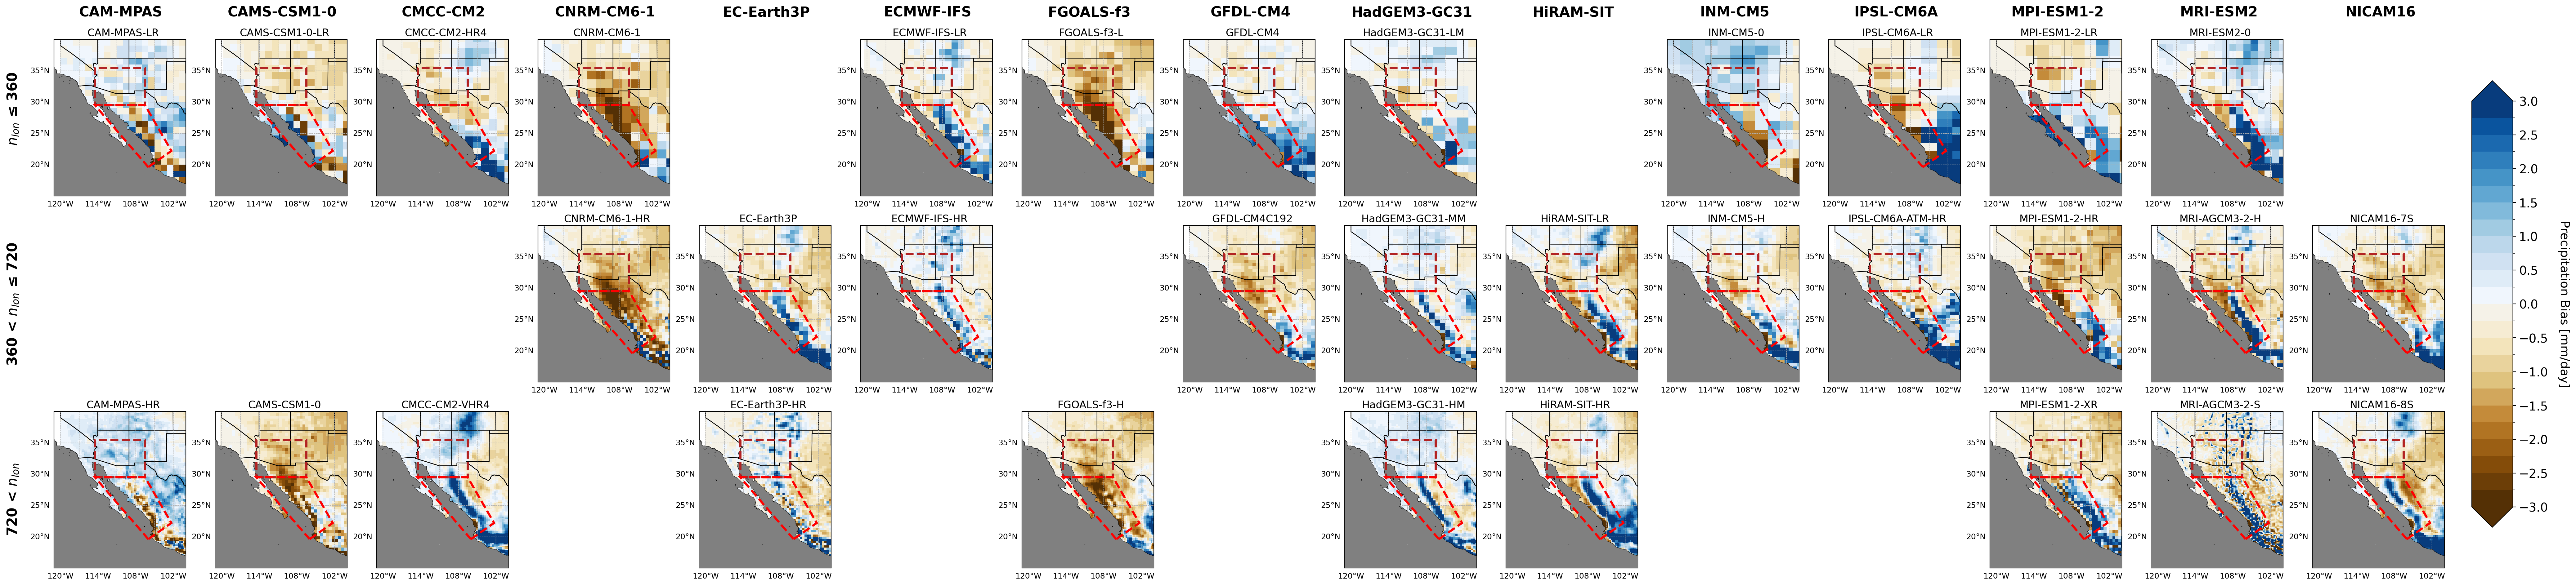

In [19]:
# obs product to plot biases against
prod = 'gpcc' # choose from: 'imerg' 'trmm' 'gpcp' 'gpcc'

# --- Settings --- #
text_kw={'color':'k', 'weight':'bold', 'size':16, 'ha':'center', 'va':'bottom'}
tx=-110
ty=40.5
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# map specs
map_tkw={'color': 'black', 'weight': 'normal', 'size':9}
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40]

# Resolution bin thresholds and labels
n_bins = 3
res_bin_labels = ['$n_{lon}$ ≤ 360', '360 < $n_{lon}$ ≤ 720', '720 < $n_{lon}$']

def get_res_bin(nlon):
    """Assign a config to resolution bin 0, 1, or 2 based on its lon grid size."""
    if nlon <= 360:
        return 0
    elif nlon <= 720:
        return 1
    else:
        return 2

families = list(lr_map.keys())

# Classify each config into a resolution bin using allmodels_res
cfg_to_bin = {cfg: get_res_bin(nlon) for cfg, nlon in allmodels_res.items()}

# For each (bin, family), collect all configs from lr_map and hr_map
bin_family_cfgs = {(b, family): [] for b in range(n_bins) for family in families}
for family in families:
    for cfg in lr_map[family] + hr_map[family]:
        if cfg in cfg_to_bin:
            bin_family_cfgs[(cfg_to_bin[cfg], family)].append(cfg)

# Each bin needs as many sub-rows as the max number of configs per family in that bin
max_rows_per_bin = [
    max(max(len(bin_family_cfgs[(b, f)]) for f in families), 1) for b in range(n_bins)
]
total_rows = sum(max_rows_per_bin)
bin_start_row = [sum(max_rows_per_bin[:b]) for b in range(n_bins)]
ncols = len(families)

fig, axes = plt.subplots(
    nrows=total_rows,
    ncols=ncols,
    figsize=(2.6*ncols, 3*total_rows),
    subplot_kw={'projection': proj},
    layout='constrained'
)

# --- Place configs and set visibility ---
cf = None
for col, family in enumerate(families):
    for b in range(n_bins):
        cfgs = bin_family_cfgs[(b, family)]
        start_row = bin_start_row[b]

        for sub_i, cfg in enumerate(cfgs):
            row = start_row + sub_i
            ax = axes[row, col]
            da = allmodels[prod][cfg]
            cf = ax.pcolormesh(da.lon, da.lat, da, cmap=dcmap, norm=dnorm, transform=trans)
            ax.text(tx, ty, cfg, fontsize=12, ha='center')

        # Hide unused sub-rows within this bin for this family
        for sub_i in range(len(cfgs), max_rows_per_bin[b]):
            axes[start_row + sub_i, col].set_visible(False)

# --- Family column labels ---
xpos = 0.0385
for col, family in enumerate(families):
    fig.text(xpos, 1.01, family, ha='center', va='bottom', fontsize=16, fontweight='bold')
    xpos = xpos + 0.0667
    
# --- Resolution bin row labels ---
for b, ypos in zip(range(n_bins),[.85, .50, .15]):
    fig.text(-0.006, ypos, res_bin_labels[b], rotation=90, ha='center', va='center', fontsize=16, fontweight='bold')

# --- Map formatting for all visible axes ---
for ax in axes.flat:
    if not ax.get_visible():
        continue

    poly1 = patches.Polygon(
        coords_map['north'],
        closed=True, ec='firebrick', fc='none', lw=2.5, ls='--',
        transform=ccrs.PlateCarree(), zorder=105
    )
    ax.add_patch(poly1)

    poly2 = patches.Polygon(
        coords_map['south'],
        closed=True, ec='red', fc='none', lw=2.5, ls='--',
        transform=ccrs.PlateCarree(), zorder=105
    )
    ax.add_patch(poly2)

    ax.coastlines(color='k', linewidth=.75)
    ax.add_feature(cfeature.STATES, linewidth=.75)
    ax.add_feature(cfeature.BORDERS, linewidth=.75)
    if prod=='gpcc':
        ax.add_feature(cfeature.OCEAN, facecolor='grey', zorder=100)
    ax.set_extent(map_bnds, crs=trans)
    gl = ax.gridlines(crs=trans, lw=.5, linestyle='--', draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style=map_tkw; gl.ylabel_style=map_tkw

# Colorbar
if cf is not None:
    cax = fig.add_axes([1.01, 0.1, 0.017, 0.8])
    cbar = fig.colorbar(cf, ticks=np.linspace(dvmin, dvmax, 13), orientation='vertical', extend='both', cax=cax)
    cbar.set_label('Precipitation Bias [mm/day]', labelpad=25, rotation=270, size=14, fontweight='normal', ha='center')
    cbar.ax.tick_params(labelsize=14)
    for tick in cbar.ax.yaxis.get_major_ticks():
        tick.label2.set_fontweight('normal')

plt.savefig(f'../figs/prec_hrmip_historical_all_{prod}_biases_maps.png', transparent=False, bbox_inches='tight')
plt.savefig(f'../figs/prec_hrmip_historical_all_{prod}_biases_maps.pdf', transparent=False, bbox_inches='tight')

### Figure S2b: Map of all HighResMIP models' historical climatologies

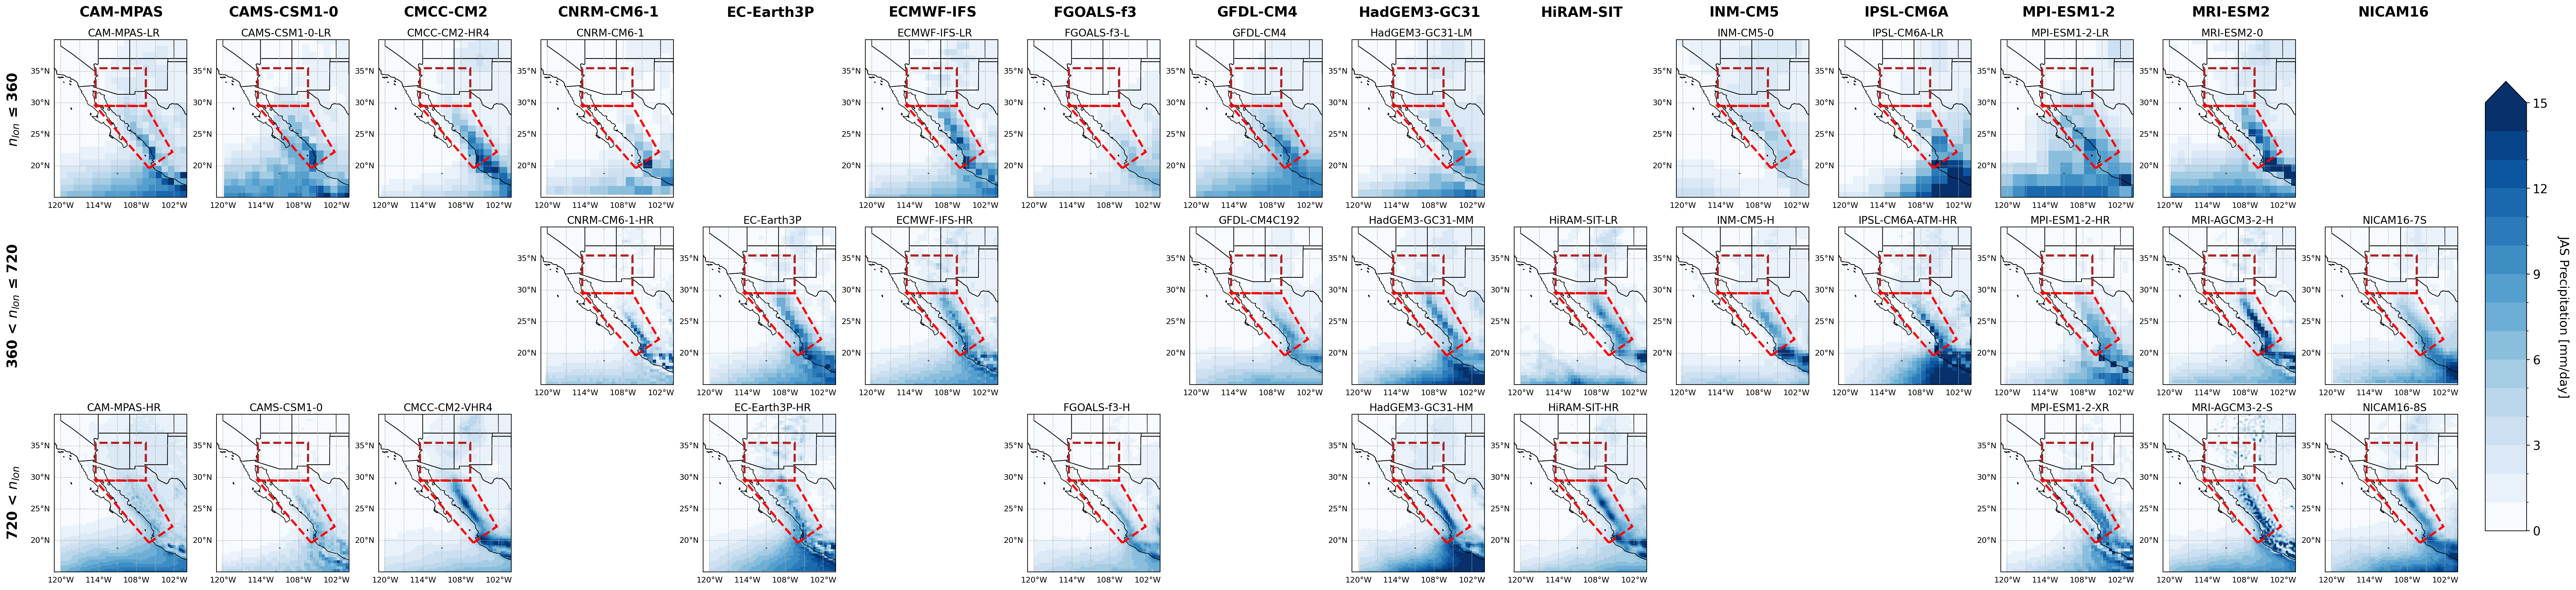

In [15]:
# --- Settings --- #
text_kw={'color':'k', 'weight':'bold', 'size':16, 'ha':'center', 'va':'bottom'}
tx=-110
ty=40.5
# climatology colormap (sequential precip)
pcmap,_,_,_=get_settings(field='precip', diff=False)
pvmin=0
pvmax=15
plevels=np.linspace(pvmin, pvmax, 16)
pnorm=mpl.colors.BoundaryNorm(plevels, pcmap.N)
# map specs
map_tkw={'color': 'black', 'weight': 'normal', 'size':9}
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40]

# Resolution bin thresholds and labels
n_bins = 3
res_bin_labels = ['$n_{lon}$ ≤ 360', '360 < $n_{lon}$ ≤ 720', '720 < $n_{lon}$']

def get_res_bin(nlon):
    """Assign a config to resolution bin 0, 1, or 2 based on its lon grid size."""
    if nlon <= 360:
        return 0
    elif nlon <= 720:
        return 1
    else:
        return 2

families = list(lr_map.keys())

# Classify each config into a resolution bin using allmodels_res
cfg_to_bin = {cfg: get_res_bin(nlon) for cfg, nlon in allmodels_res.items()}

# For each (bin, family), collect all configs from lr_map and hr_map
bin_family_cfgs = {(b, family): [] for b in range(n_bins) for family in families}
for family in families:
    for cfg in lr_map[family] + hr_map[family]:
        if cfg in cfg_to_bin:
            bin_family_cfgs[(cfg_to_bin[cfg], family)].append(cfg)

# Each bin needs as many sub-rows as the max number of configs per family in that bin
max_rows_per_bin = [
    max(max(len(bin_family_cfgs[(b, f)]) for f in families), 1) for b in range(n_bins)
]
total_rows = sum(max_rows_per_bin)
bin_start_row = [sum(max_rows_per_bin[:b]) for b in range(n_bins)]
ncols = len(families)

fig, axes = plt.subplots(
    nrows=total_rows,
    ncols=ncols,
    figsize=(2.6*ncols, 3*total_rows),
    subplot_kw={'projection': proj},
    layout='constrained'
)

# --- Place configs and set visibility ---
cf = None
for col, family in enumerate(families):
    for b in range(n_bins):
        cfgs = bin_family_cfgs[(b, family)]
        start_row = bin_start_row[b]

        for sub_i, cfg in enumerate(cfgs):
            row = start_row + sub_i
            ax = axes[row, col]
            da = allmodels_climo[cfg]
            cf = ax.pcolormesh(da.lon, da.lat, da, cmap=pcmap, norm=pnorm, transform=trans)
            ax.text(tx, ty, cfg, fontsize=12, ha='center')

        # Hide unused sub-rows within this bin for this family
        for sub_i in range(len(cfgs), max_rows_per_bin[b]):
            axes[start_row + sub_i, col].set_visible(False)

# --- Family column labels ---
xpos = 0.0385
for col, family in enumerate(families):
    fig.text(xpos, 1.01, family, ha='center', va='bottom', fontsize=16, fontweight='bold')
    xpos = xpos + 0.0667

# --- Resolution bin row labels ---
for b, ypos in zip(range(n_bins),[.85, .50, .15]):
    fig.text(-0.006, ypos, res_bin_labels[b], rotation=90, ha='center', va='center', fontsize=16, fontweight='bold')

# --- Map formatting for all visible axes ---
for ax in axes.flat:
    if not ax.get_visible():
        continue

    poly1 = patches.Polygon(
        coords_map['north'],
        closed=True, ec='firebrick', fc='none', lw=2.5, ls='--',
        transform=ccrs.PlateCarree(), zorder=105
    )
    ax.add_patch(poly1)

    poly2 = patches.Polygon(
        coords_map['south'],
        closed=True, ec='red', fc='none', lw=2.5, ls='--',
        transform=ccrs.PlateCarree(), zorder=105
    )
    ax.add_patch(poly2)

    ax.coastlines(color='k', linewidth=.75)
    ax.add_feature(cfeature.STATES, linewidth=.75)
    ax.add_feature(cfeature.BORDERS, linewidth=.75)
    ax.set_extent(map_bnds, crs=trans)
    gl = ax.gridlines(crs=trans, lw=.5, linestyle='--', draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style=map_tkw; gl.ylabel_style=map_tkw

# Colorbar
if cf is not None:
    cax = fig.add_axes([1.01, 0.1, 0.017, 0.8])
    cbar = fig.colorbar(cf, ticks=np.linspace(pvmin, pvmax, 6), orientation='vertical', extend='max', cax=cax)
    cbar.set_label('JAS Precipitation [mm/day]', labelpad=25, rotation=270, size=14, fontweight='normal', ha='center')
    cbar.ax.tick_params(labelsize=14)

plt.savefig('../figs/prec_hrmip_historical_all_climatologies_maps.png', transparent=False, bbox_inches='tight')
plt.savefig('../figs/prec_hrmip_historical_all_climatologies_maps.pdf', transparent=False, bbox_inches='tight')


### Figure S3: HighResMIP multi-model ensemble mean biases vs. all obs products

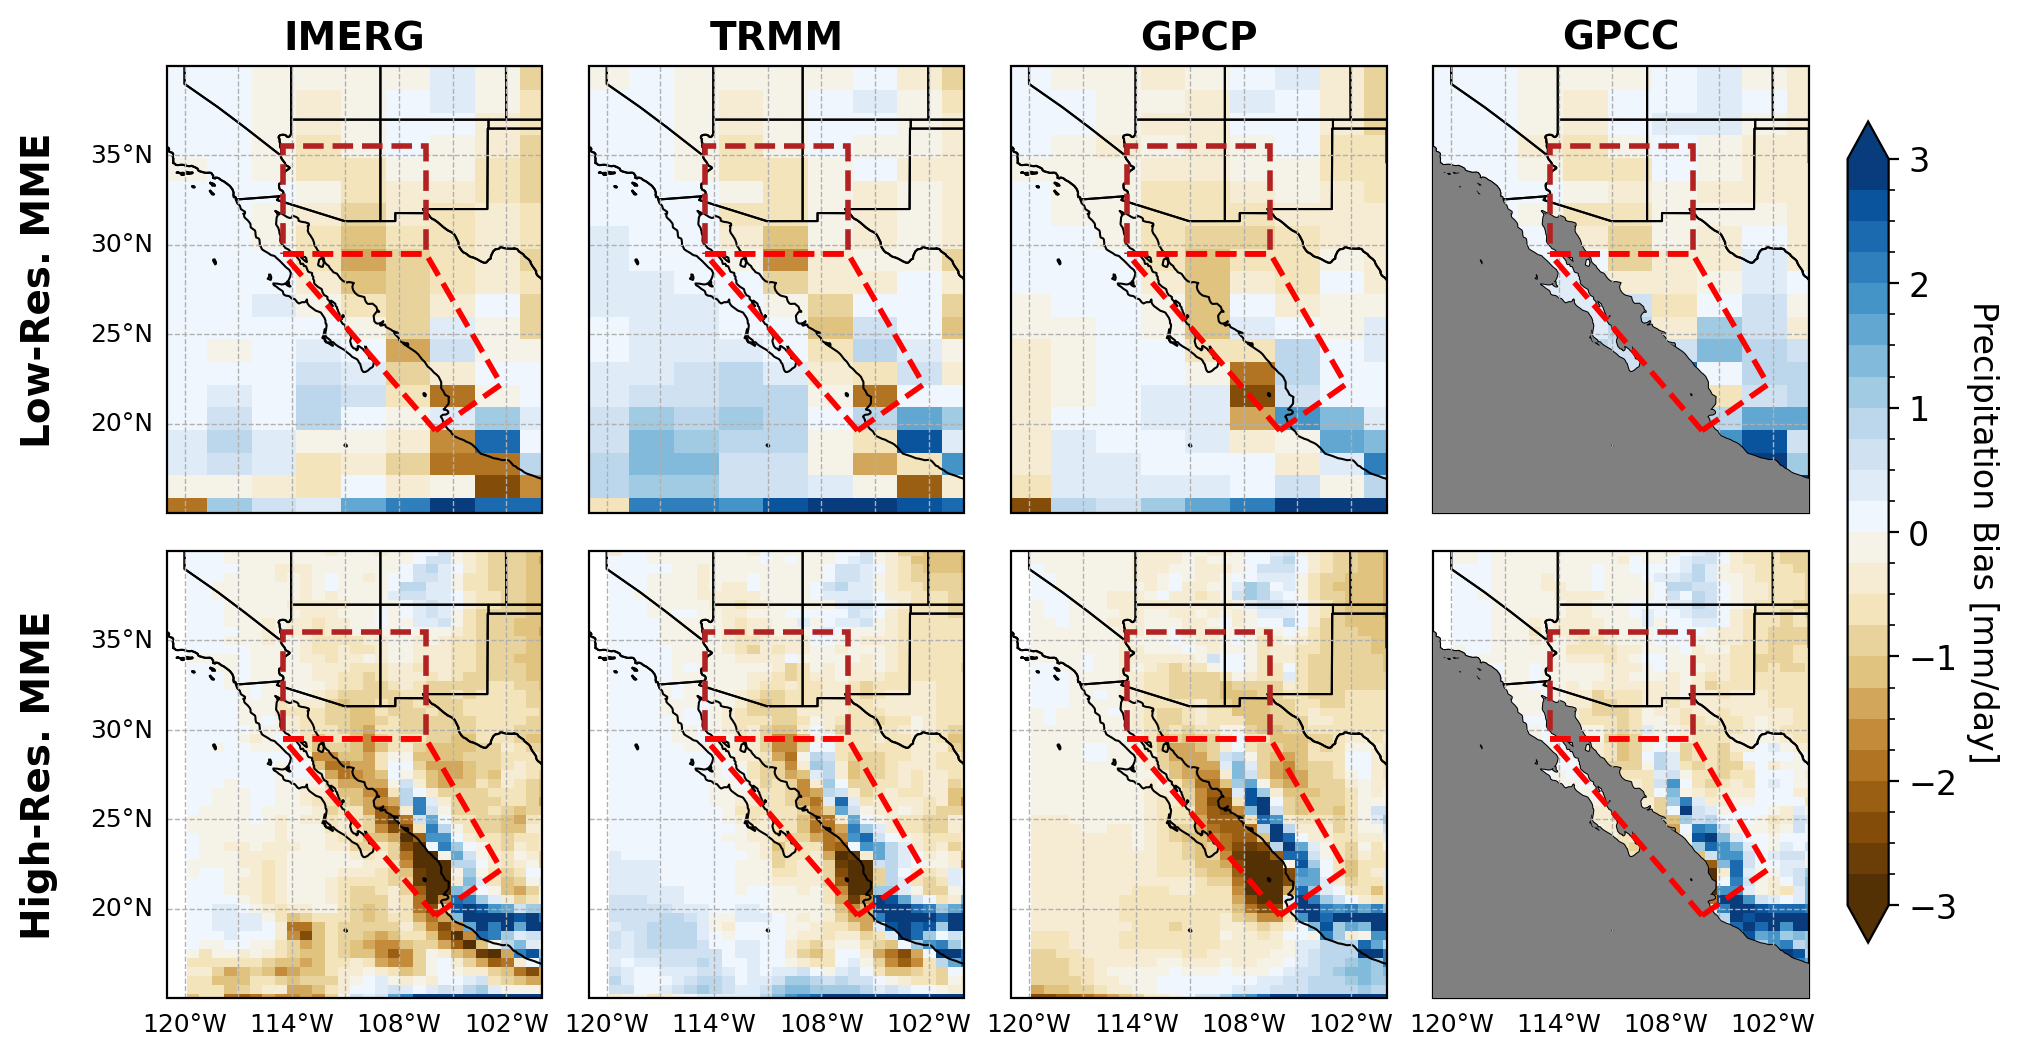

In [24]:
# --- Multi-model ensemble mean biases vs. all obs products --- #

prods = ['imerg', 'trmm', 'gpcp', 'gpcc']
prod_labels = {'imerg': 'IMERG', 'trmm': 'TRMM', 'gpcp': 'GPCP', 'gpcc': 'GPCC'}
row_cfgs = ['lr', 'hr']
row_labels = {'lr': 'Low-Res. MME', 'hr': 'High-Res. MME'}

# bias colormap
dcmap,_,_,_ = get_settings(field='precip', diff=True)
dvmin, dvmax = -3, 3
dlevels = np.linspace(dvmin, dvmax, 25)
dnorm = mpl.colors.BoundaryNorm(dlevels, dcmap.N)

# map specs
map_tkw = {'color': 'black', 'weight': 'normal', 'size': 9}
trans = ccrs.PlateCarree()
proj = ccrs.PlateCarree()
map_bnds = [239, 260, 15, 40]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(10,5.2), subplot_kw={'projection': proj}, layout='constrained')

cf = None
for r, config in enumerate(row_cfgs):
    for c, prod in enumerate(prods):
        ax = axes[r, c]
        da = mme[config][prod]
        cf = ax.pcolormesh(da.lon, da.lat, da, cmap=dcmap, norm=dnorm,
                           transform=trans, edgecolors='face', linewidth=0)

        # NAM sub-domain outlines
        ax.add_patch(patches.Polygon(coords_map['north'], closed=True, ec='firebrick',
                     fc='none', lw=2, ls='--', transform=trans, zorder=105))
        ax.add_patch(patches.Polygon(coords_map['south'], closed=True, ec='red',
                     fc='none', lw=2, ls='--', transform=trans, zorder=105))

        # map formatting
        ax.coastlines(color='k', linewidth=.75)
        ax.add_feature(cfeature.STATES, linewidth=.75)
        ax.add_feature(cfeature.BORDERS, linewidth=.75)
        if prod=='gpcc':
            ax.add_feature(cfeature.OCEAN, facecolor='grey', zorder=100)
        ax.set_extent(map_bnds, crs=trans)
        gl = ax.gridlines(crs=trans, lw=.5, linestyle='--', draw_labels=True)
        gl.bottom_labels = (r == 1); gl.left_labels = (c == 0)
        gl.top_labels = False; gl.right_labels = False
        gl.xformatter = LONGITUDE_FORMATTER; gl.yformatter = LATITUDE_FORMATTER
        gl.xlabel_style = map_tkw; gl.ylabel_style = map_tkw

        # column titles (top row only)
        if r == 0:
            ax.set_title(prod_labels[prod], fontsize=14, fontweight='bold')

# row labels (left of column 0, tracks axes position under constrained_layout)
for r, config in enumerate(row_cfgs):
    axes[r, 0].text(-0.34, 0.5, row_labels[config], transform=axes[r, 0].transAxes,
                    rotation=90, ha='center', va='center', fontsize=14, fontweight='bold')

# shared colorbar
cbar = fig.colorbar(cf, ax=axes, ticks=np.linspace(dvmin, dvmax, 7),
                    orientation='vertical', extend='both', fraction=0.025, pad=0.02)
cbar.set_label('Precipitation Bias [mm/day]', labelpad=15, rotation=270, size=12, ha='center')
cbar.ax.tick_params(labelsize=12)

plt.savefig('../figs/prec_hrmip_historical_mme_biases_all_obs.png', transparent=False, bbox_inches='tight')
plt.savefig('../figs/prec_hrmip_historical_mme_biases_all_obs.pdf', transparent=False, bbox_inches='tight')


### Figure S2: Seasonal precipitation climatologies

In [25]:
## +++ COMPUTE & CACHE DOMAIN-MEAN MONTHLY CLIMATOLOGIES (Fig. S4) +++ ##

coords_map, regions = nam_regions()
domains = ['south', 'north']

climo_cache = os.path.join(cache_dir, 'monthly_climo_by_domain.nc')

if os.path.exists(climo_cache):
    print("Loading domain-mean monthly climatologies from cache...")
    ds_climo = xr.open_dataset(climo_cache)
else:
    print("Computing domain-mean monthly climatologies (cache will be written)...")
    climo_vars = {}
    for res in ['lr', 'hr']:
        for cfg, ds in dat_na[res].items():
            climo_vars[cfg] = (regional_weighted_mean(ds, regions)
                               .groupby('time.month').mean('time'))
    for prod in ['imerg', 'trmm']:
        climo_vars[prod] = (regional_weighted_mean(obs_dat_na[prod], regions)
                            .groupby('time.month').mean('time'))
    ds_climo = xr.Dataset(climo_vars).load()
    ds_climo.to_netcdf(climo_cache)
    print(f"Saved {climo_cache}")

# Repackage into the dicts the plotting cell expects: {domain: {name: climatology}}
monthly_climo = {d: {} for d in domains}
monthly_climo_obs = {d: {} for d in domains}
model_cfgs = all_cfgs['lr'] + all_cfgs['hr']
for d in domains:
    for cfg in model_cfgs:
        monthly_climo[d][cfg] = ds_climo[cfg].sel(region=d)
    for prod in ['imerg', 'trmm']:
        monthly_climo_obs[d][prod] = ds_climo[prod].sel(region=d)

print('Done.')


Computing domain-mean monthly climatologies (cache will be written)...
Saved ../highresmip_diagnostics/cache/monthly_climo_by_domain.nc
Done.


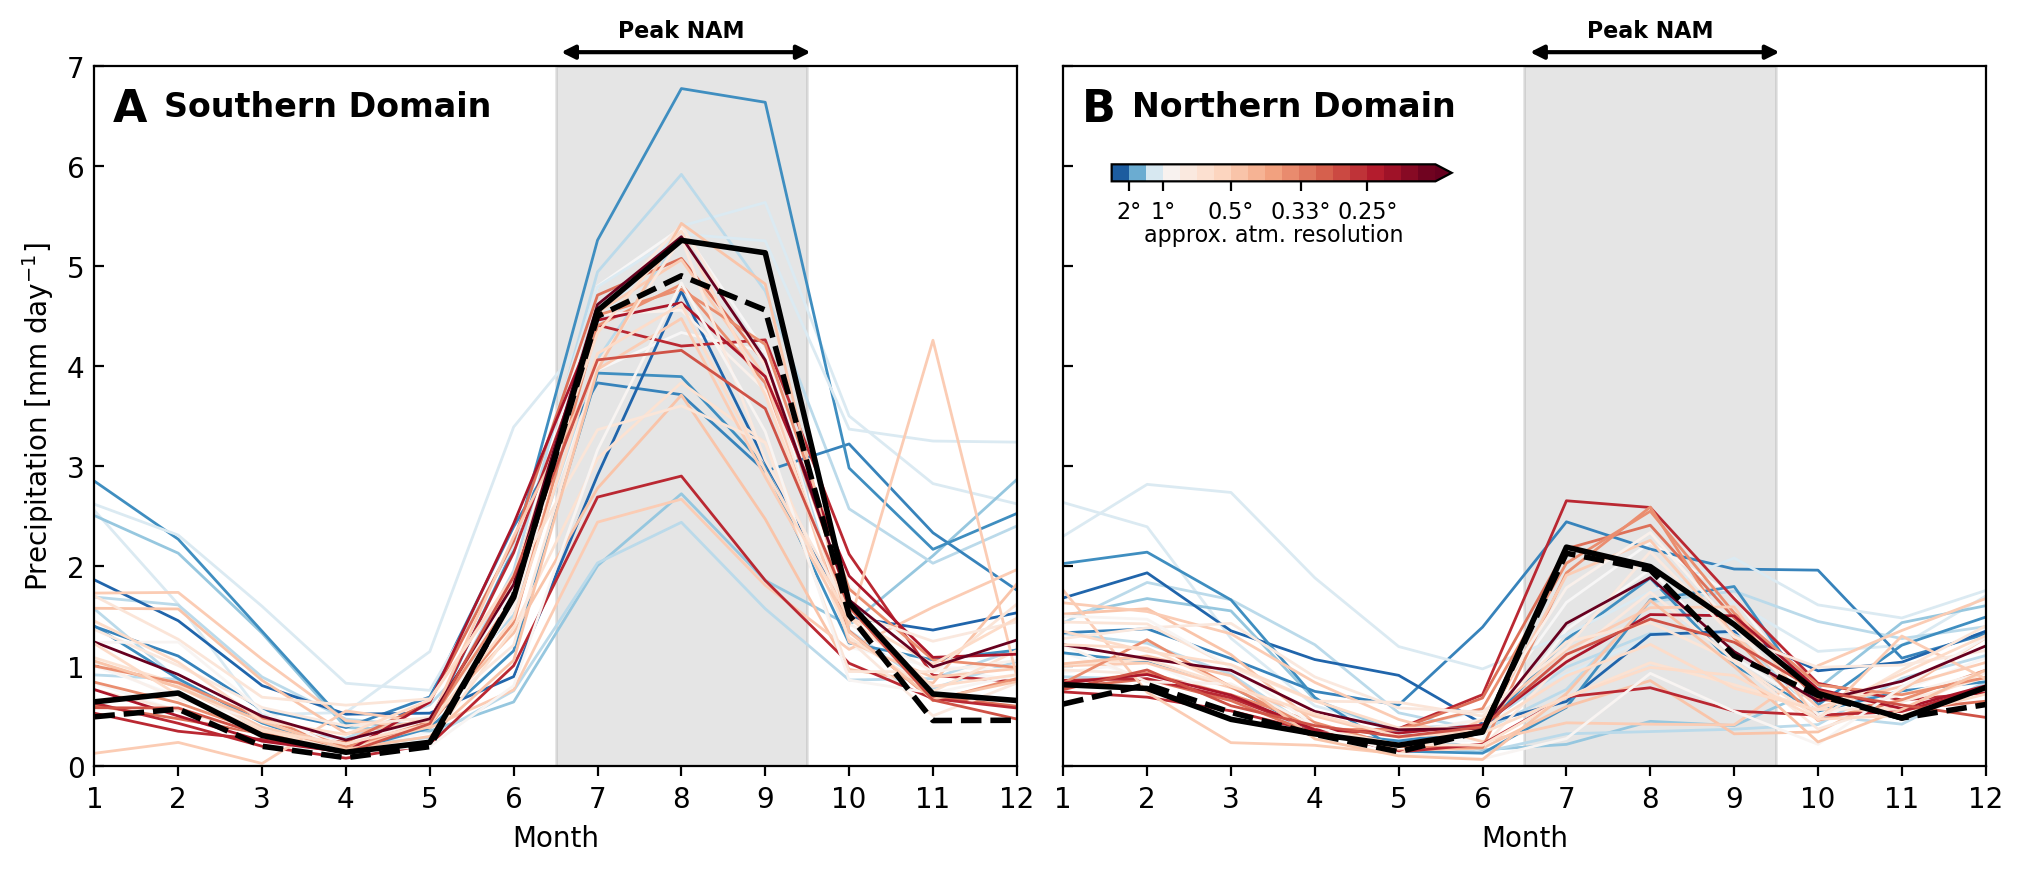

In [61]:
# --- Settings --- #
legend_kw = {'loc':'upper left', 'bbox_to_anchor':(1.02, 1.0), 'ncol':1,
             'fontsize':7, 'labelcolor':'linecolor', 'frameon':False, 'handlelength':1, 'handletextpad':0.5}
text_kw={'size':14, 'weight':'bold', 'color':'k', 'ha':'center', 'va':'center'}
text_kw1={'size':8, 'weight':'bold', 'color':'k', 'ha':'center', 'va':'center'}
line_kw={'ls':'-', 'lw':1}
tkw = {'axis':'y', 'direction':'in', 'labelsize':10}
patch_kw = {'ec':'k', 'lw':1, 'ls':'-', 'fc':'k', 'alpha':0.1}
arrow_kw={'arrowstyle':'<|-|>', 'color':'k', 'linewidth':1.5}
# resolution colormap
cmap = cm.RdBu_r
vmin, vmax, vcenter = 90, 1800, 360
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
levels = np.linspace(vmin, vmax, 20)

# (Domain-mean climatologies are precomputed/cached in the preceding cell as
#  monthly_climo[domain][cfg] and monthly_climo_obs[domain][prod].)

# --- Figure --- #
panel_labels = {'south': 'A', 'north': 'B'}
panel_titles = {'south': 'Southern Domain', 'north': 'Northern Domain'}

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4.25), sharey=True, layout='constrained')

for ax, domain in zip(axes, domains):
    # hrmip models, colored by resolution
    for cfg, ds in monthly_climo[domain].items():
        color = cmap(norm(allmodels_res[cfg]))
        ax.plot(ds.month, ds, c=color, label=cfg, **line_kw)
    # obs products
    ax.plot(monthly_climo_obs[domain]['imerg'].month, monthly_climo_obs[domain]['imerg'],
            c='k', label='imerg', ls='-', lw=2)
    ax.plot(monthly_climo_obs[domain]['trmm'].month, monthly_climo_obs[domain]['trmm'],
            c='k', label='trmm', ls='--', lw=2)

    # shade peak NAM (Jul.-Sept.) and annotate above the axis
    ax.axvspan(6.5, 9.5, zorder=1, label='_Hidden', **patch_kw)
    xtr = ax.get_xaxis_transform()
    ax.text(8, 1.05, 'Peak NAM', transform=xtr, clip_on=False, **text_kw1)
    ax.annotate('', xy=(6.5/13, 1.02), xytext=(9.5/12.14, 1.02),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=arrow_kw, clip_on=False)
    #ax.text(8.5, 1.02, 'Jul.$-$Sept.', backgroundcolor='white',
    #        transform=xtr, zorder=100, clip_on=False, **text_kw1)

    # panel label + domain name (top-left, over the dry-season part of the curves)
    ax.text(0.02, 0.97, panel_labels[domain], transform=ax.transAxes,
            ha='left', va='top', size=16, weight='bold')
    ax.text(0.075, 0.965, panel_titles[domain], transform=ax.transAxes,
            ha='left', va='top', size=12, weight='bold')

    # formatting
    ax.set(xlim=[1, 12], xticks=np.arange(1, 13, 1), ylim=[0, 7], yticks=np.arange(0, 8, 1))
    ax.set_xlabel('Month', color='k')
    ax.tick_params(color='k', labelcolor='k', **tkw)

axes[0].set_ylabel('Precipitation [mm day$^{-1}$]', color='k')

# per-model resolution legend (identical models in both panels) to the right
#axes[1].legend(**legend_kw)

# --- shared resolution colorbar beneath the panels --- #
dlons = [2.0, 1.0, 0.5, 0.33, 0.25]
tick_nlons = [360.0 / d for d in dlons]

cax=fig.add_axes([0.55, .8, 0.17, 0.02])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax, boundaries=levels, ticks=tick_nlons, spacing="proportional",
                    extend='max',orientation='horizontal')
cbar.set_label("approx. atm. resolution", labelpad=0, size=8, rotation=0)
cbar.set_ticklabels([f"{d:g}°" for d in dlons])
cbar.ax.tick_params(labelsize=8)

# --- save fig --- #
plt.savefig('../figs/prec_hrmip_monthly_climo_by_domain.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../figs/prec_hrmip_monthly_climo_by_domain.png', transparent=False, bbox_inches='tight')


### Misc. Figures

In [12]:
## +++ EXTRA PLOTTING FUNCTIONS +++ ##

def collect_lr_hr_pairs(domain):
    x_lr = []
    y_hr = []
    parents = []

    for model in models:
        if not lr_map[model] or not hr_map[model]:
            continue
        lr_cfg = lr_map[model][0]
        if lr_cfg not in nam_bias['lr'][domain]:
            continue
        lr_val = nam_bias['lr'][domain][lr_cfg]['bias'].values.item()

        for hr_cfg in hr_map[model]:
            if hr_cfg not in nam_bias['hr'][domain]:
                continue
            hr_val = nam_bias['hr'][domain][hr_cfg]['bias'].values.item()
            x_lr.append(lr_val)
            y_hr.append(hr_val)
            parents.append(model)

    return np.array(x_lr), np.array(y_hr), parents

def collect_resolution_delta_bias_mag(domain):
    x_res = []
    y_dmag = []
    parents = []

    for model in models:
        if not lr_map[model] or not hr_map[model]:
            continue
        lr_cfg = lr_map[model][0]
        if lr_cfg not in nam_bias['lr'][domain]:
            continue
        lr_bias = nam_bias['lr'][domain][lr_cfg]['bias'].values.item()
        lr_mag  = abs(lr_bias)
        lr_nlon = allmodels_res[lr_cfg]

        for hr_cfg in hr_map[model]:
            if hr_cfg not in nam_bias['hr'][domain]:
                continue
            hr_bias = nam_bias['hr'][domain][hr_cfg]['bias'].values.item()
            hr_mag  = abs(hr_bias)
            hr_nlon = allmodels_res[hr_cfg]

            # longitudinal resolution refinement
            x = np.log2(hr_nlon / lr_nlon)

            # change in bias magnitude (intuitive sign)
            y = hr_mag - lr_mag

            x_res.append(x)
            y_dmag.append(y)
            parents.append(model)

    return np.array(x_res), np.array(y_dmag), parents

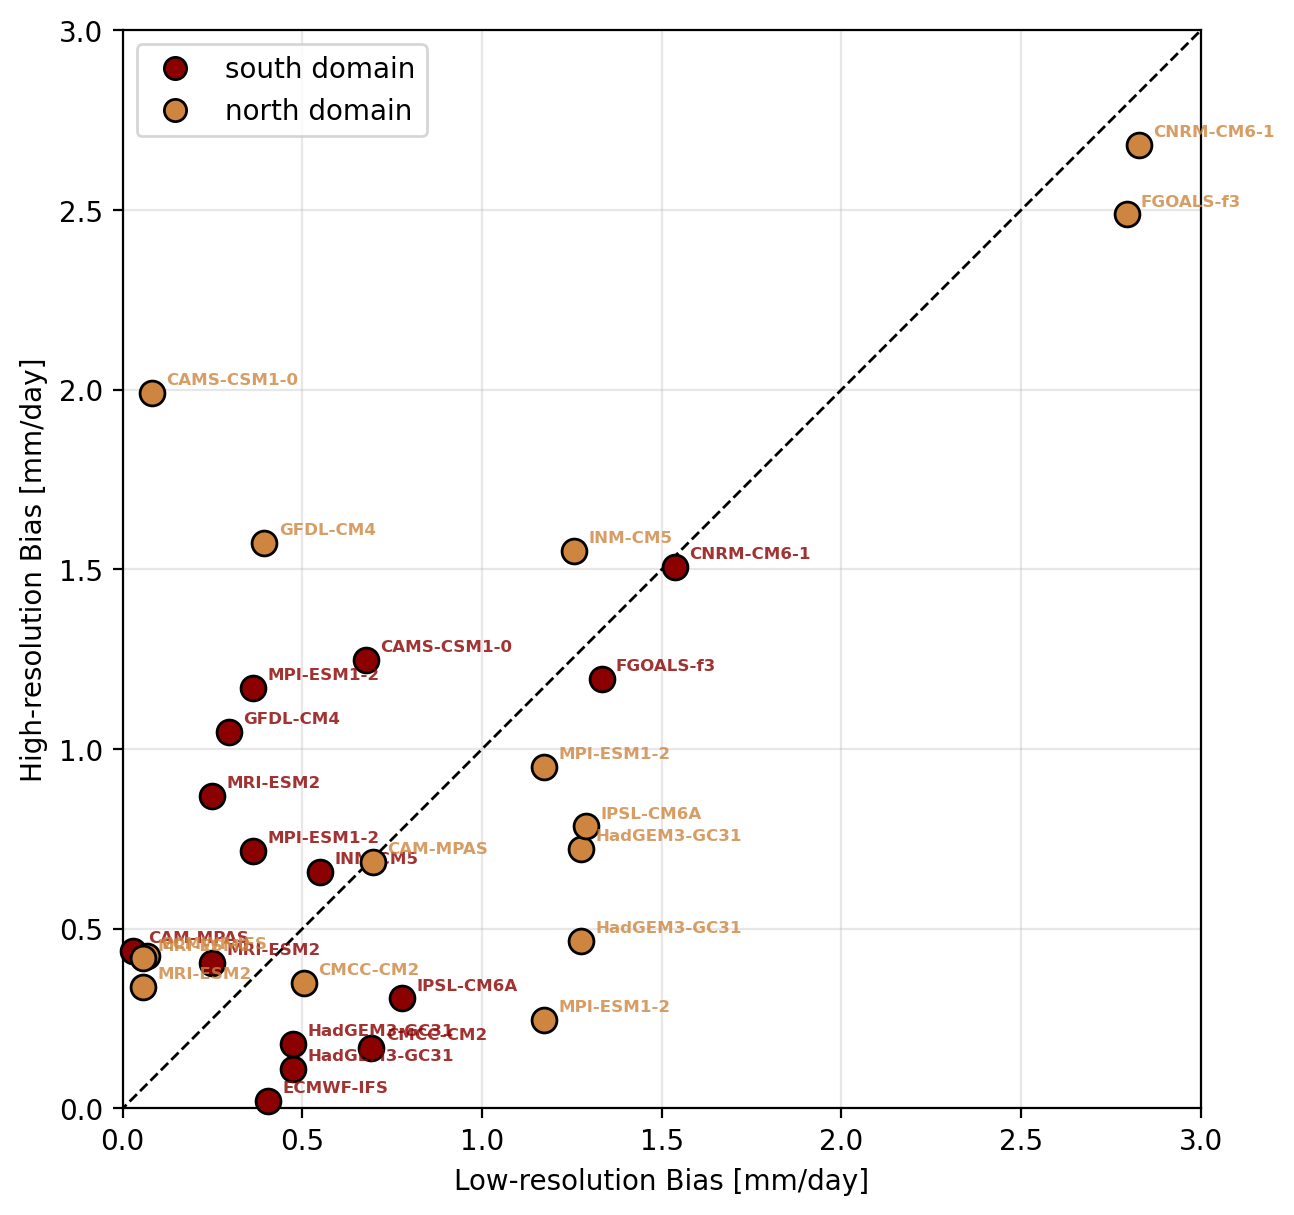

In [43]:
marker_cols=['darkred','peru']
label_text_kw=dict(fontsize=6, fontweight='bold', ha='left', va='bottom', alpha=0.8)
fig, ax = plt.subplots(figsize=(7,7))

for i,domain in enumerate(domains):
    mkr_col=marker_cols[i]
    x_lr, y_hr, parents = collect_lr_hr_pairs(domain)
    ax.scatter(abs(x_lr), abs(y_hr),
               s=80, c=mkr_col, edgecolor='k',
               alpha=1, clip_on=False, zorder=100)

    dx, dy = 0.04, 0.015
    for x, y, parent in zip(abs(x_lr), abs(y_hr), parents):
        ax.text(x+dx, y+dy, parent, color=mkr_col, zorder=100, **label_text_kw)
    
# 1:1 reference line
lims = [min(x_lr.min(), y_hr.min())-2, max(x_lr.max(), y_hr.max())+3]
ax.plot(lims, lims, 'k--', lw=1)
ax.set(xlabel='Low-resolution Bias [mm/day]',  xlim=[0,3],
       ylabel='High-resolution Bias [mm/day]', ylim=[0,3])
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

legend_kw={'loc':'upper left', 'bbox_to_anchor':(0,1), 'ncol':1, 'fontsize':10, 'labelcolor':'k', 'frameon':True}
legend_handles = [ Line2D([0], [0], marker='o', color='w', alpha=1,
                       mec='k', mfc='darkred',
                       markersize=8, label='south domain'),
                    Line2D([0], [0], marker='o', color='w', alpha=1,
                       mec='k', mfc='peru',
                       markersize=8, label='north domain') ]
ax.legend(handles=legend_handles, **legend_kw)

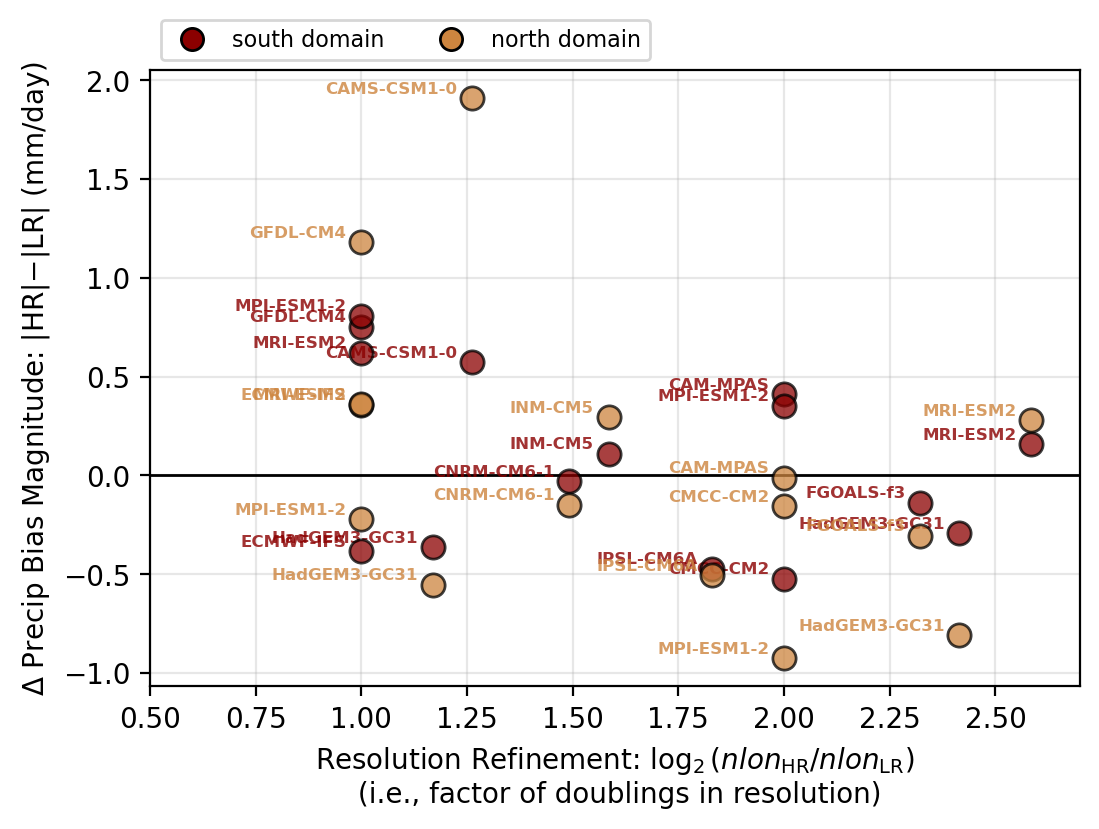

In [44]:
# Plot of change in horizontal resolution (as a factor in the number of doublings, where a factor of 1.0 = 2x increase in resolution (e.g., nlon=180 to nlon=360)
# compared to change in the magnitude of bias between HR and LR configurations of the same model family
# positive change in bias magnitude = bias worsened; negative change in bias magnitude = bias improved/reduced

marker_cols=['darkred','peru']
label_text_kw=dict(fontsize=6, fontweight='bold', ha='right', va='bottom', alpha=0.8)
fig, ax = plt.subplots(figsize=(6,4))

for i,domain in enumerate(domains):
    mkr_col=marker_cols[i]
    x_res, y_dbias, parents = collect_resolution_delta_bias_mag(domain)
    
    ax.scatter(x_res, y_dbias,
               s=70, c=mkr_col, edgecolor='k',
               alpha=0.75, zorder=100)

    dx, dy = -0.035, 0.01
    for x, y, parent in zip(x_res, y_dbias, parents):
        ax.text(x+dx, y+dy, parent, color=mkr_col, **label_text_kw)

# reference lines
ax.axhline(0, color='k', lw=1)   # no bias change
ax.axvline(0, color='k', lw=1)   # no resolution change

ax.set(xlabel=r'Resolution Refinement: $\log_2(nlon_{\mathrm{HR}} / nlon_{\mathrm{LR}})$'
               '\n (i.e., factor of doublings in resolution)',
       ylabel='$\Delta$ Precip Bias Magnitude: |HR|$−$|LR| (mm/day)',
       xlim=[0.5,2.7])

ax.grid(True, alpha=0.3)

legend_kw={'loc':'upper left', 'bbox_to_anchor':(0,1.1), 'ncol':2, 'fontsize':8, 'labelcolor':'k', 'frameon':True}
legend_handles = [ Line2D([0], [0], marker='o', color='w', alpha=1,
                       mec='k', mfc='darkred',
                       markersize=8, label='south domain'),
                    Line2D([0], [0], marker='o', color='w', alpha=1,
                       mec='k', mfc='peru',
                       markersize=8, label='north domain') ]
ax.legend(handles=legend_handles, **legend_kw)